In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

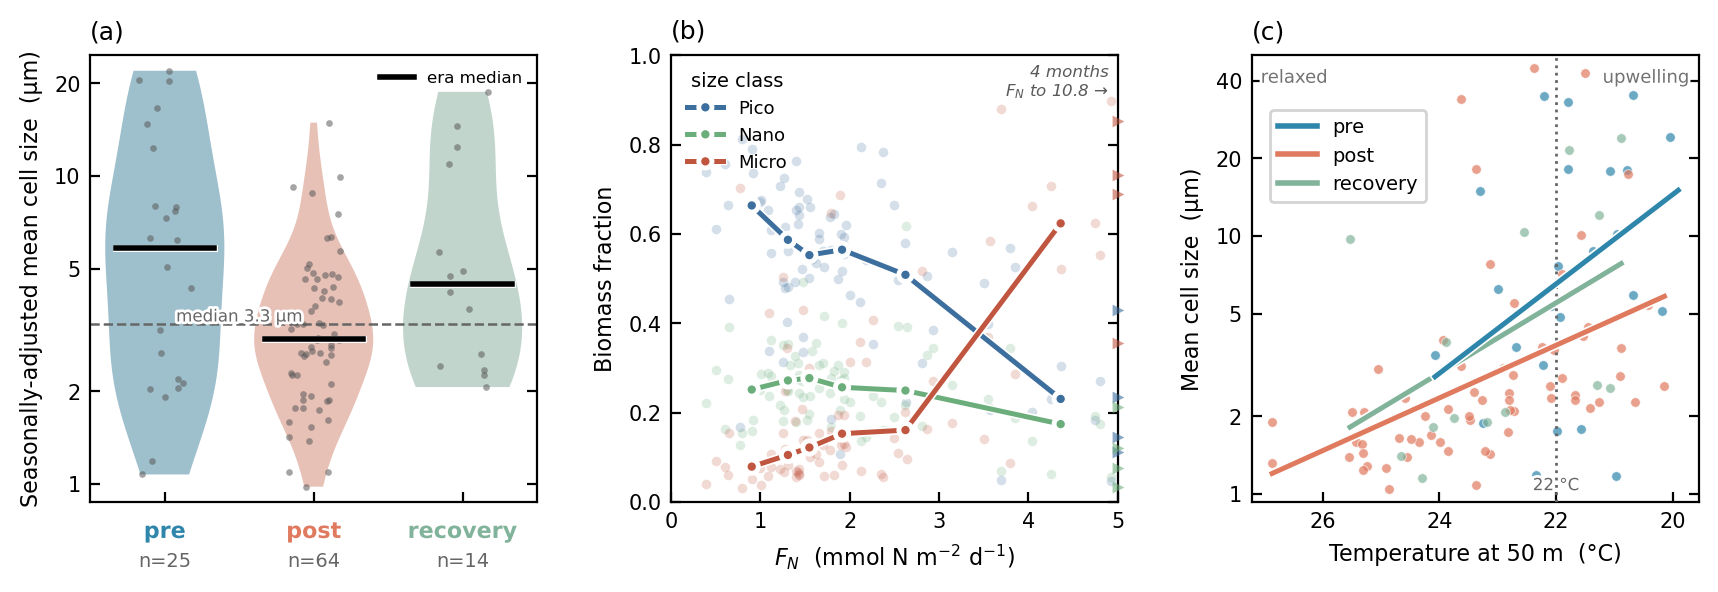

In [21]:
%config InlineBackend.figure_format = 'retina'
# Figure 3 — (a) MCS by era | (b) P/N/M vs F_N | (c) MCS vs temperature
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
UM_TICKS_A = [1, 2, 5, 10, 20]
UM_TICKS_C = [1, 2, 5, 10, 20, 40]
HALO = [pe.withStroke(linewidth=2.5, foreground='white')]
HALO3 = [pe.withStroke(linewidth=3.0, foreground='white')]
LBL_HALO = [pe.withStroke(linewidth=2, foreground='white')]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
df['mcs_log'] = df['size_centroid']
df['mo'] = df['date'].dt.month

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(8.6, 3.2))
fig.subplots_adjust(left=0.06, right=0.995, top=0.90, bottom=0.17, wspace=0.30)
for ax in (axA, axB, axC):
    ax.set_box_aspect(1)

# ---------------- (a) MCS era violin, seasonally-adjusted µm ----------------
dA = df.dropna(subset=['mcs_log']).copy()
dA['mcs_anom'] = dA['mcs_log'] - dA.groupby('mo')['mcs_log'].transform('mean')
GM = dA['mcs_log'].mean()
dA['mcs_adj'] = dA['mcs_anom'] + GM
sns.violinplot(data=dA, x='era', y='mcs_adj', order=ERA_ORDER, hue='era',
               palette=ERA_COL, legend=False, inner=None, cut=0, linewidth=0.8, ax=axA)
for v in axA.collections:
    v.set_alpha(0.50); v.set_edgecolor('none')
sns.stripplot(data=dA, x='era', y='mcs_adj', order=ERA_ORDER, color='0.35',
              size=2.4, alpha=0.55, jitter=0.18, ax=axA)
for i, e in enumerate(ERA_ORDER):
    s = dA[dA.era == e]
    axA.plot([i - 0.33, i + 0.33], [s['mcs_adj'].median()] * 2, color='black', lw=2.0,
             zorder=6, path_effects=HALO)
overall_med = dA['mcs_adj'].median()
axA.axhline(overall_med, color='0.4', ls='--', lw=0.9, zorder=1)
axA.text(0.5, overall_med, f'median {10 ** overall_med:.1f} µm', ha='center', va='bottom',
         fontsize=6, color='0.4', path_effects=LBL_HALO, zorder=7)
axA.set_xlim(-0.5, 2.5)
axA.set_ylim(dA['mcs_adj'].min() - 0.05, dA['mcs_adj'].max() + 0.05)
axA.set_yticks([np.log10(u) for u in UM_TICKS_A]); axA.set_yticklabels(UM_TICKS_A)
axA.set_ylabel('Seasonally-adjusted mean cell size  (µm)', fontsize=8)
axA.set_xlabel(''); axA.set_title('(a)', loc='left', fontsize=9)
axA.tick_params(top=False, right=True, direction='in', labelsize=7.5)
axA.set_xticks(range(3)); axA.set_xticklabels([])
for i, e in enumerate(ERA_ORDER):
    axA.text(i, -0.04, e, transform=axA.get_xaxis_transform(), ha='center', va='top',
             fontsize=8, color=ERA_COL[e], fontweight='bold', clip_on=False, path_effects=LBL_HALO)
    axA.text(i, -0.11, f'n={len(dA[dA.era == e])}', transform=axA.get_xaxis_transform(),
             ha='center', va='top', fontsize=7, color='0.4', clip_on=False)
axA.legend(handles=[Line2D([0], [0], color='black', lw=2, label='era median')],
           loc='upper right', frameon=False, fontsize=6)

# ---------------- (b) P/N/M fraction vs F_N ----------------
FNCOL, XCUT = 'FN_mmolN_m2_d', 5.0
BINS = [('Pico', 'pico_mmolN', '#3C6E9E'),
        ('Nano', 'nano_mmolN', '#6BAE7B'),
        ('Micro', 'micro_mmolN', '#C0563F')]
binc = [c for _, c, _ in BINS]
dB = df.dropna(subset=binc + [FNCOL]).copy()
tot = dB[binc].sum(axis=1)
for name, c, _ in BINS:
    dB[name + '_frac'] = dB[c] / tot
dB['fn_bin'] = pd.qcut(dB[FNCOL], 6, duplicates='drop')
centers = dB.groupby('fn_bin', observed=True)[FNCOL].median()
inb, oob = dB[dB[FNCOL] <= XCUT], dB[dB[FNCOL] > XCUT]
for name, c, col in BINS:
    axB.scatter(inb[FNCOL], inb[name + '_frac'], s=12, color=col, alpha=0.22, lw=0, zorder=2)
    axB.scatter(np.full(len(oob), XCUT), oob[name + '_frac'], marker='>', s=18,
                color=col, alpha=0.6, lw=0, zorder=6, clip_on=False)
    med = dB.groupby('fn_bin', observed=True)[name + '_frac'].median()
    axB.plot(centers.values, med.values, color=col, lw=1.8, marker='o', ms=3.5,
             mec='white', mew=0.5, zorder=5, path_effects=HALO3, label=name)
axB.set_xlim(0, XCUT); axB.set_ylim(0, 1)
axB.xaxis.set_major_locator(MaxNLocator(nbins=5))
axB.tick_params(top=False, right=True, direction='in', labelsize=7.5)
axB.set_xlabel('$F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
axB.set_ylabel('Biomass fraction', fontsize=8)
axB.set_title('(b)', loc='left', fontsize=9)
axB.text(0.98, 0.98, f'{len(oob)} months\n$F_N$ to {dB[FNCOL].max():.1f} →',
         transform=axB.transAxes, ha='right', va='top', fontsize=6, color='0.35', style='italic')
axB.legend(title='size class', frameon=False, fontsize=6.5, title_fontsize=7, loc='upper left')

# ---------------- (c) MCS vs temperature at 50 m ----------------
XCOL, XTHRESH = 'temp_50m', 22.0
dC = df.dropna(subset=['mcs_log', XCOL]).copy()
zmap = {'pre': 7, 'post': 6, 'recovery': 5}
for e in ERA_ORDER:
    s = dC[dC.era == e]
    axC.scatter(s[XCOL], s['mcs_log'], s=12, color=ERA_COL[e], alpha=0.7,
                edgecolor='white', linewidth=0.3, zorder=3)
    if len(s) >= 8:
        b = np.polyfit(s[XCOL], s['mcs_log'], 1)
        xx = np.linspace(s[XCOL].min(), s[XCOL].max(), 50)
        axC.plot(xx, np.polyval(b, xx), color=ERA_COL[e], lw=1.8, zorder=zmap[e], path_effects=HALO3)
axC.axvline(XTHRESH, color='0.4', ls=':', lw=1.0, zorder=4)
axC.invert_xaxis()
axC.set_ylim(dC['mcs_log'].min() - 0.05, dC['mcs_log'].max() + 0.05)
axC.set_yticks([np.log10(u) for u in UM_TICKS_C]); axC.set_yticklabels(UM_TICKS_C)
axC.xaxis.set_major_locator(MaxNLocator(nbins=5))
axC.set_ylabel('Mean cell size  (µm)', fontsize=8)
axC.set_xlabel('Temperature at 50 m  (°C)', fontsize=8)
axC.set_title('(c)', loc='left', fontsize=9)
axC.tick_params(top=False, right=True, direction='in', labelsize=7.5)
axC.text(XTHRESH, 0.02, '22 °C', transform=axC.get_xaxis_transform(), ha='center', va='bottom',
         fontsize=6, color='0.4', path_effects=LBL_HALO)
axC.text(0.02, 0.97, 'relaxed', transform=axC.transAxes, ha='left', va='top',
         fontsize=6.5, color='0.45', path_effects=LBL_HALO)
axC.text(0.98, 0.97, 'upwelling', transform=axC.transAxes, ha='right', va='top',
         fontsize=6.5, color='0.45', path_effects=LBL_HALO)
axC.legend(handles=[Line2D([0], [0], color=ERA_COL[e], lw=2, label=e) for e in ERA_ORDER],
           loc='upper left', bbox_to_anchor=(0.02, 0.90), frameon=True, framealpha=0.85,
           edgecolor='0.8', fontsize=7)

# fig.savefig('figure3.pdf', bbox_inches='tight')   # uncomment to export
plt.show()

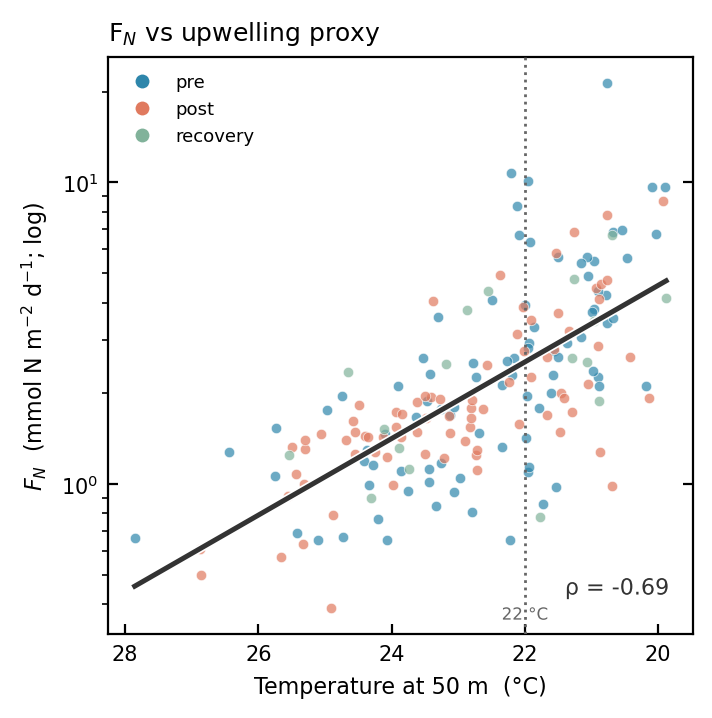

group        n  rho(F_N,temp50)         p
all        185           -0.695   5.5e-28
pre         88           -0.697   4.8e-14
post        80           -0.716   8.4e-14
recovery    17           -0.623    0.0076


In [22]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 add-on — F_N vs temp_50m: coupling between the obs upwelling proxy and the model forcing.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
LBL_HALO = [pe.withStroke(linewidth=2, foreground='white')]
XCOL, XTHRESH, FNCOL = 'temp_50m', 22.0, 'FN_mmolN_m2_d'

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=[FNCOL, XCOL]).copy()

fig, ax = plt.subplots(figsize=(3.7, 3.7))
fig.subplots_adjust(left=0.17, right=0.96, top=0.93, bottom=0.15)
for e in ERA_ORDER:
    s = d[d.era == e]
    ax.scatter(s[XCOL], s[FNCOL], s=14, color=ERA_COL[e], alpha=0.7,
               edgecolor='white', linewidth=0.3, zorder=3)
b = np.polyfit(d[XCOL], np.log10(d[FNCOL]), 1)          # overall trend, fit in log-F_N
xx = np.linspace(d[XCOL].min(), d[XCOL].max(), 50)
ax.plot(xx, 10 ** np.polyval(b, xx), color='0.2', lw=1.8, zorder=5, path_effects=HALO)

ax.axvline(XTHRESH, color='0.4', ls=':', lw=1.0, zorder=4)
ax.set_yscale('log'); ax.invert_xaxis()
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_xlabel('Temperature at 50 m  (°C)', fontsize=8)
ax.set_ylabel('$F_N$  (mmol N m$^{-2}$ d$^{-1}$; log)', fontsize=8)
ax.set_title('F$_N$ vs upwelling proxy', loc='left', fontsize=9)
ax.text(XTHRESH, 0.02, '22 °C', transform=ax.get_xaxis_transform(), ha='center', va='bottom',
        fontsize=6, color='0.4', path_effects=LBL_HALO)

rho, p = spearmanr(d[XCOL], d[FNCOL])
ax.text(0.96, 0.06, f'ρ = {rho:+.2f}', transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, color='0.2', path_effects=LBL_HALO)
ax.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=ERA_COL[e],
          markersize=6, label=e) for e in ERA_ORDER], loc='upper left', frameon=False, fontsize=6.5)
plt.show()

print(f"{'group':9s} {'n':>4s} {'rho(F_N,temp50)':>16s} {'p':>9s}")
for e in ['all'] + ERA_ORDER:
    s = d if e == 'all' else d[d.era == e]
    r, pp = spearmanr(s[XCOL], s[FNCOL])
    print(f"{e:9s} {len(s):>4d} {r:>16.3f} {pp:>9.2g}")

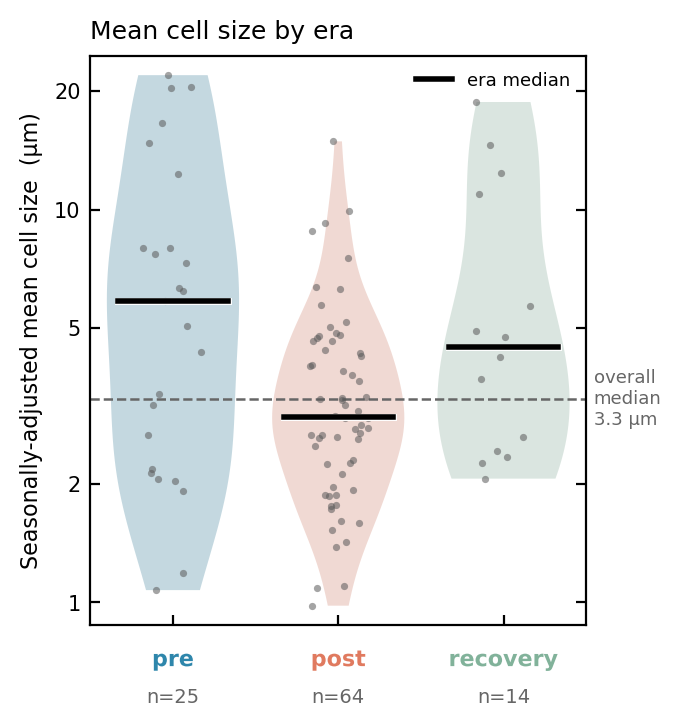

In [12]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 Panel 1 — MCS era violin (seasonally-adjusted µm).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
UM_TICKS = [1, 2, 5, 10, 20]
HALO = [pe.withStroke(linewidth=2.5, foreground='white')]
LBL_HALO = [pe.withStroke(linewidth=2, foreground='white')]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['size_centroid']).copy()
d['mo'] = d['date'].dt.month
d['mcs_anom'] = d['size_centroid'] - d.groupby('mo')['size_centroid'].transform('mean')
GM = d['size_centroid'].mean()
d['mcs_adj'] = d['mcs_anom'] + GM

fig, ax = plt.subplots(figsize=(3.7, 3.7))
fig.subplots_adjust(left=0.17, right=0.84, top=0.93, bottom=0.16)
sns.violinplot(data=d, x='era', y='mcs_adj', order=ERA_ORDER, hue='era',
               palette=ERA_COL, legend=False, inner=None, cut=0, linewidth=0.8, ax=ax)
for v in ax.collections:
    v.set_alpha(0.30); v.set_edgecolor('none')
sns.stripplot(data=d, x='era', y='mcs_adj', order=ERA_ORDER, color='0.35',
              size=2.6, alpha=0.55, jitter=0.18, ax=ax)
for i, e in enumerate(ERA_ORDER):
    s = d[d.era == e]
    ax.plot([i - 0.33, i + 0.33], [s['mcs_adj'].median()] * 2, color='black', lw=2.0,
            zorder=6, path_effects=HALO)

overall_med = d['mcs_adj'].median()
ax.axhline(overall_med, color='0.4', ls='--', lw=0.9, zorder=1)
ax.text(1.015, overall_med, f'overall\nmedian\n{10 ** overall_med:.1f} µm', transform=ax.get_yaxis_transform(),
        va='center', ha='left', fontsize=6.5, color='0.4')

ax.set_xlim(-0.5, 2.5)
ax.set_ylim(d['mcs_adj'].min() - 0.05, d['mcs_adj'].max() + 0.05)
ax.set_yticks([np.log10(u) for u in UM_TICKS]); ax.set_yticklabels(UM_TICKS)
ax.set_ylabel('Seasonally-adjusted mean cell size  (µm)', fontsize=8)
ax.set_xlabel('')
ax.set_title('Mean cell size by era', loc='left', fontsize=9)
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)

# era names as Fig-1-styled x labels (ticks kept), n beneath
ax.set_xticks(range(3)); ax.set_xticklabels([])
for i, e in enumerate(ERA_ORDER):
    ax.text(i, -0.04, e, transform=ax.get_xaxis_transform(), ha='center', va='top',
            fontsize=8, color=ERA_COL[e], fontweight='bold', clip_on=False, path_effects=LBL_HALO)
    ax.text(i, -0.11, f'n={len(d[d.era == e])}', transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=7, color='0.4', clip_on=False)

ax.legend(handles=[Line2D([0], [0], color='black', lw=2, label='era median')],
          loc='upper right', frameon=False, fontsize=6.5)
plt.show()

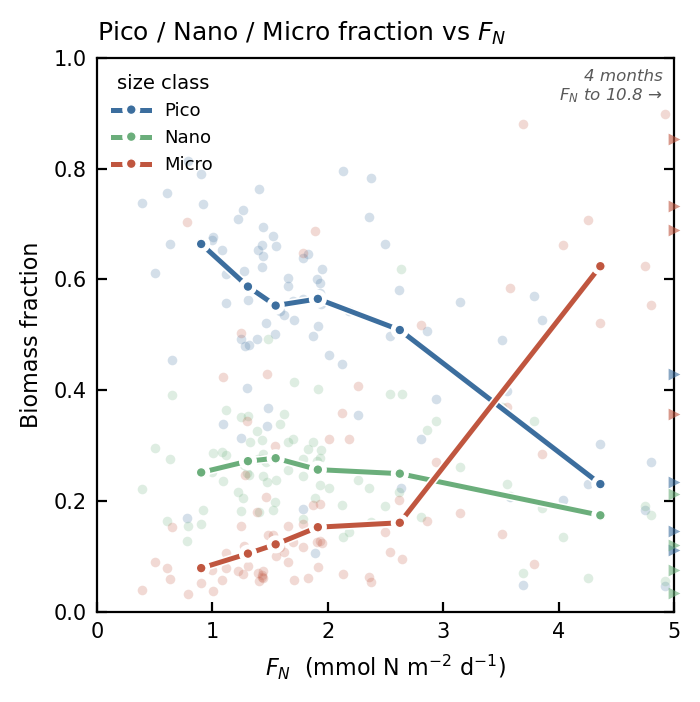

off-scale (F_N>5.0): n=4; median P/N/M = 0.19/0.10/0.71


In [5]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 Panel 2 — Pico/Nano/Micro biomass fraction vs F_N (linear, view cut at 5; off-scale flagged).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from cariaco_obs import DEFAULT_CSV_PATH

HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
FNCOL = 'FN_mmolN_m2_d'
XCUT = 5.0
BINS = [('Pico', 'pico_mmolN', '#3C6E9E'),
        ('Nano', 'nano_mmolN', '#6BAE7B'),
        ('Micro', 'micro_mmolN', '#C0563F')]
cols = [c for _, c, _ in BINS]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d = df.dropna(subset=cols + [FNCOL]).copy()
tot = d[cols].sum(axis=1)
for name, c, _ in BINS:
    d[name + '_frac'] = d[c] / tot
d['fn_bin'] = pd.qcut(d[FNCOL], 6, duplicates='drop')
centers = d.groupby('fn_bin', observed=True)[FNCOL].median()
meds = {name: d.groupby('fn_bin', observed=True)[name + '_frac'].median() for name, _, _ in BINS}

inb, oob = d[d[FNCOL] <= XCUT], d[d[FNCOL] > XCUT]

fig, ax = plt.subplots(figsize=(3.7, 3.6))
fig.subplots_adjust(left=0.16, right=0.94, top=0.92, bottom=0.15)
for name, c, col in BINS:
    ax.scatter(inb[FNCOL], inb[name + '_frac'], s=12, color=col, alpha=0.22, lw=0, zorder=2)
    ax.scatter(np.full(len(oob), XCUT), oob[name + '_frac'], marker='>', s=18,
               color=col, alpha=0.6, lw=0, zorder=6, clip_on=False)          # off-scale flag
    ax.plot(centers.values, meds[name].values, color=col, lw=1.8, marker='o', ms=3.5,
            mec='white', mew=0.5, zorder=5, path_effects=HALO, label=name)

ax.set_xlim(0, XCUT); ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_xlabel('$F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
ax.set_ylabel('Biomass fraction', fontsize=8)
ax.set_title('Pico / Nano / Micro fraction vs $F_N$', loc='left', fontsize=9)
ax.text(0.98, 0.98, f'{len(oob)} months\n$F_N$ to {d[FNCOL].max():.1f} →',
        transform=ax.transAxes, ha='right', va='top', fontsize=6, color='0.35', style='italic')
ax.legend(title='size class', frameon=False, fontsize=6.5, title_fontsize=7, loc='upper left')
plt.show()

print(f"off-scale (F_N>{XCUT}): n={len(oob)}; median P/N/M = "
      f"{oob['Pico_frac'].median():.2f}/{oob['Nano_frac'].median():.2f}/{oob['Micro_frac'].median():.2f}")

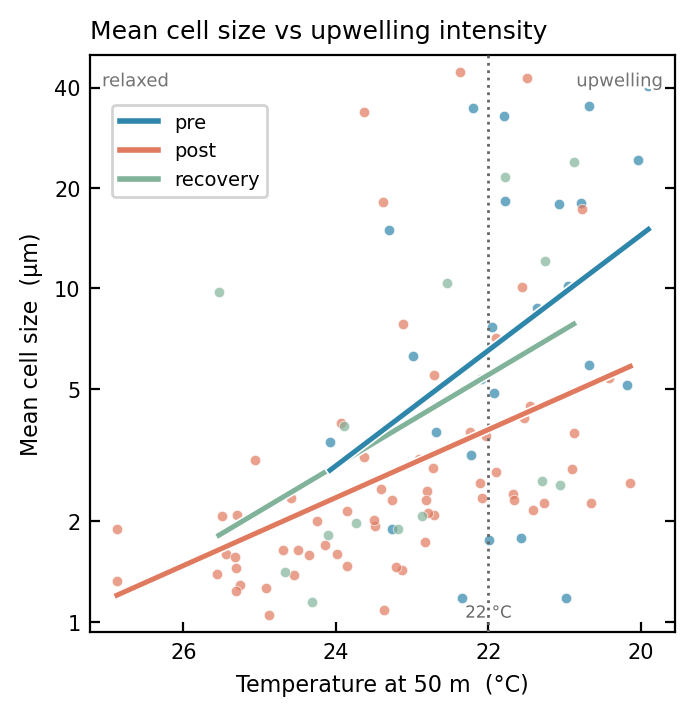

era          n  slope(log µm/°C)     rho         p
all        103           -0.1405  -0.589   5.8e-11
pre         25           -0.1732  -0.425     0.034
post        64           -0.1020  -0.648   7.1e-09
recovery    14           -0.1362  -0.618     0.019


In [17]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 Panel 3 — Mean cell size vs temperature at 50 m, by era. x inverted so upwelling (cold) is on the right.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
UM_TICKS = [1, 2, 5, 10, 20, 40]
HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
LBL_HALO = [pe.withStroke(linewidth=2, foreground='white')]
XCOL, XTHRESH = 'temp_50m', 22.0

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
df['mcs_log'] = df['size_centroid']                    # log10 MCS (µm)
d = df.dropna(subset=['mcs_log', XCOL]).copy()

fig, ax = plt.subplots(figsize=(3.7, 3.7))
fig.subplots_adjust(left=0.17, right=0.96, top=0.93, bottom=0.15)
for e in ERA_ORDER:
    s = d[d.era == e]
    ax.scatter(s[XCOL], s['mcs_log'], s=14, color=ERA_COL[e], alpha=0.7,
               edgecolor='white', linewidth=0.3, zorder=3)
    if len(s) >= 8:
        b = np.polyfit(s[XCOL], s['mcs_log'], 1)
        xx = np.linspace(s[XCOL].min(), s[XCOL].max(), 50)
        ax.plot(xx, np.polyval(b, xx), color=ERA_COL[e], lw=1.8,
                zorder={'pre': 7, 'post': 6, 'recovery': 5}[e], path_effects=HALO)

ax.axvline(XTHRESH, color='0.4', ls=':', lw=1.0, zorder=4)
ax.invert_xaxis()                                      # upwelling (cold) -> right

ax.set_ylim(d['mcs_log'].min() - 0.05, d['mcs_log'].max() + 0.05)
ax.set_yticks([np.log10(u) for u in UM_TICKS]); ax.set_yticklabels(UM_TICKS)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.set_ylabel('Mean cell size  (µm)', fontsize=8)
ax.set_xlabel('Temperature at 50 m  (°C)', fontsize=8)
ax.set_title('Mean cell size vs upwelling intensity', loc='left', fontsize=9)
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)

ax.text(XTHRESH, 0.02, '22 °C', transform=ax.get_xaxis_transform(), ha='center', va='bottom',
        fontsize=6, color='0.4', path_effects=LBL_HALO)
ax.text(0.02, 0.97, 'relaxed', transform=ax.transAxes, ha='left', va='top',
        fontsize=6.5, color='0.45', path_effects=LBL_HALO)
ax.text(0.98, 0.97, 'upwelling', transform=ax.transAxes, ha='right', va='top',
        fontsize=6.5, color='0.45', path_effects=LBL_HALO)

# era legend (identifies the regression lines), top-left
ax.legend(handles=[Line2D([0], [0], color=ERA_COL[e], lw=2, label=e) for e in ERA_ORDER],
          loc='upper left', bbox_to_anchor=(0.02, 0.93), frameon=True, framealpha=0.85,
          edgecolor='0.8', fontsize=7)
plt.show()

print(f"{'era':9s} {'n':>4s} {'slope(log µm/°C)':>17s} {'rho':>7s} {'p':>9s}")
for e in ['all', 'pre', 'post', 'recovery']:
    s = d if e == 'all' else d[d.era == e]
    rho, p = spearmanr(s[XCOL], s['mcs_log'])
    b = np.polyfit(s[XCOL], s['mcs_log'], 1)
    print(f"{e:9s} {len(s):>4d} {b[0]:>17.4f} {rho:>7.3f} {p:>9.2g}")

In [18]:
# Panel 3 backing stats — ANCOVA: does era shift MCS at matched forcing, for temp AND F_N?
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
df['mcs_log'] = df['size_centroid']        # log10 MCS (µm)

def run_ancova(forcing, label):
    d = df.dropna(subset=['mcs_log', forcing]).copy()
    print(f"\n================  MCS vs {label}  (n={len(d)})  ================")

    # 1) additive ANCOVA (parallel slopes) — era term = level-shift at matched forcing
    add = smf.ols(f'mcs_log ~ {forcing} + C(era, Treatment(reference="post"))', data=d).fit()
    aov = sm.stats.anova_lm(add, typ=2)
    print("\nAdditive model  mcs_log ~ forcing + era:")
    print(aov.round(4))
    era_row = [r for r in aov.index if 'era' in r][0]
    print(f"  -> era level-shift: F={aov.loc[era_row, 'F']:.2f}  p={aov.loc[era_row, 'PR(>F)']:.3g}")
    print("  adjusted era offsets vs post (at matched forcing):")
    for name, coef in add.params.items():
        if 'C(era' in name:
            who = name.split('[T.')[1].rstrip(']')
            print(f"    {who:9s} {coef:+.3f} log10 µm = {10 ** coef:.2f}x   (p={add.pvalues[name]:.3g})")

    # 2) interaction model — do the slopes differ by era?
    inter = smf.ols(f'mcs_log ~ {forcing} * C(era, Treatment(reference="post"))', data=d).fit()
    aovi = sm.stats.anova_lm(inter, typ=2)
    ix = [r for r in aovi.index if ':' in r][0]
    print(f"\nInteraction (slope difference): F={aovi.loc[ix, 'F']:.2f}  p={aovi.loc[ix, 'PR(>F)']:.3g}"
          f"   (n.s. => parallel slopes; clean level-shift)")

    # 3) annual-mean robustness (independence cross-check)
    ann = (d.assign(yr=d.date.dt.year)
             .groupby('yr').agg(mcs_log=('mcs_log', 'mean'), f=(forcing, 'mean')).reset_index())
    ann['era'] = np.where(ann.yr < 2005, 'pre', np.where(ann.yr < 2014, 'post', 'recovery'))
    add_a = smf.ols('mcs_log ~ f + C(era, Treatment(reference="post"))', data=ann).fit()
    aov_a = sm.stats.anova_lm(add_a, typ=2)
    er = [r for r in aov_a.index if 'era' in r][0]
    print(f"\nAnnual-mean robustness (n_years={len(ann)}): era F={aov_a.loc[er, 'F']:.2f}  "
          f"p={aov_a.loc[er, 'PR(>F)']:.3g}")

for forcing, label in [('temp_50m', 'temperature at 50 m'), ('FN_mmolN_m2_d', 'F_N')]:
    run_ancova(forcing, label)

print("\nNote: OLS SEs assume independent months, but months are autocorrelated -> these p's are "
      "optimistic; the annual-mean ANCOVA is the independence check. era term = vertical offset at "
      "matched forcing (top-down candidate); interaction = whether slopes genuinely differ.")


================  MCS vs temperature at 50 m  (n=103)  ================

Additive model  mcs_log ~ forcing + era:
                                      sum_sq    df        F  PR(>F)
C(era, Treatment(reference="post"))   0.8950   2.0   3.2625  0.0424
temp_50m                              2.9051   1.0  21.1791  0.0000
Residual                             13.5797  99.0      NaN     NaN
  -> era level-shift: F=3.26  p=0.0424
  adjusted era offsets vs post (at matched forcing):
    pre       +0.237 log10 µm = 1.73x   (p=0.0147)
    recovery  +0.128 log10 µm = 1.34x   (p=0.246)

Interaction (slope difference): F=0.48  p=0.62   (n.s. => parallel slopes; clean level-shift)

Annual-mean robustness (n_years=15): era F=3.55  p=0.0646

================  MCS vs F_N  (n=94)  ================

Additive model  mcs_log ~ forcing + era:
                                     sum_sq    df        F  PR(>F)
C(era, Treatment(reference="post"))  0.2132   2.0   1.0896  0.3408
FN_mmolN_m2_d                     

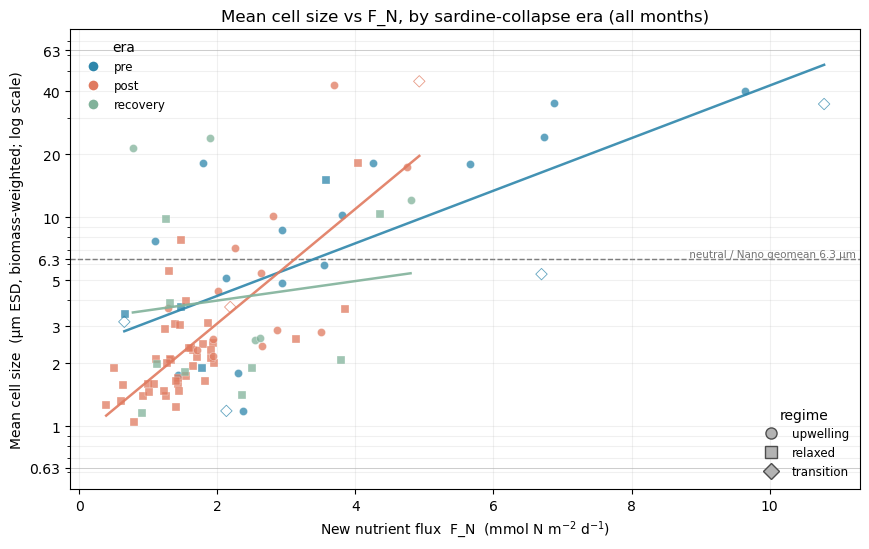

era          n   OLS slope  intercept     rho         p
(slope = log10 µm per unit F_N; Spearman rho is scale-invariant)
all         94      0.1620     0.1859   0.574   1.5e-09
pre         23      0.1258     0.3718   0.712   0.00014
post        57      0.2741    -0.0566   0.707   7.9e-10
recovery    14      0.0466     0.5076   0.160      0.58


In [2]:
# Fig 3 pre-step — Mean cell size (MCS, µm) vs F_N, by sardine-collapse era.
# F_N analogue of the existing temp_50m era panel. All months; regime by marker.
# Run from code/ so cariaco_obs resolves.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

PICO_UM, NANO_UM, MICRO_UM = 0.63, 6.3, 63.0     # Sieburth bin geomeans
NEUTRAL_UM = NANO_UM                              # uniform composition = 6.3 µm (=10^0.80)
FNCOL = 'FN_mmolN_m2_d'

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['mcs_um'] = 10.0 ** df['size_centroid']       # mean cell size, µm
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['mcs_um', FNCOL]).copy()
if 'regime_adjusted' in d.columns:
    d['regime_adjusted'] = d['regime_adjusted'].fillna('unknown')
else:
    d['regime_adjusted'] = 'unknown'

era_order = ['pre', 'post', 'recovery']
ecol = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
reg_mk = {'upwelling': 'o', 'relaxed': 's', 'transition': 'D'}

fig, ax = plt.subplots(figsize=(8.8, 5.6))
for e in era_order:
    s = d[d.era == e]
    for r, sr in s.groupby('regime_adjusted'):
        m = reg_mk.get(r, 'x')
        face = 'none' if r == 'transition' else ecol[e]
        edge = ecol[e] if r == 'transition' else 'white'
        ax.scatter(sr[FNCOL], sr.mcs_um, marker=m, s=34, alpha=0.75, facecolor=face,
                   edgecolor=edge, linewidth=0.6 if r == 'transition' else 0.3, zorder=3)
    if len(s) >= 8:                                # per-era OLS in log10(MCS) space
        b = np.polyfit(s[FNCOL], np.log10(s.mcs_um), 1)
        xx = np.linspace(s[FNCOL].min(), s[FNCOL].max(), 50)
        ax.plot(xx, 10.0 ** np.polyval(b, xx), color=ecol[e], lw=1.8, alpha=0.9, zorder=4)

ax.axhline(NEUTRAL_UM, color='0.45', ls='--', lw=1, zorder=1)
ax.text(0.995, NEUTRAL_UM, ' neutral / Nano geomean 6.3 µm', transform=ax.get_yaxis_transform(),
        ha='right', va='bottom', fontsize=7.5, color='0.45')
for y in (PICO_UM, MICRO_UM):
    ax.axhline(y, color='0.8', lw=0.6, zorder=1)

ax.set_yscale('log')
um_ticks = [0.63, 1, 2, 3, 5, 6.3, 10, 20, 40, 63]
ax.set_yticks(um_ticks); ax.set_yticklabels([str(t) for t in um_ticks])
ax.set_ylabel('Mean cell size  (µm ESD, biomass-weighted; log scale)')
ax.set_xlabel('New nutrient flux  F_N  (mmol N m$^{-2}$ d$^{-1}$)')
ax.set_title('Mean cell size vs F_N, by sardine-collapse era (all months)')

eh = [Line2D([0], [0], marker='o', color='w', markerfacecolor=ecol[e], markersize=8, label=e)
      for e in era_order]
rh = [Line2D([0], [0], marker=m, color='0.3', markerfacecolor='0.7', linestyle='',
      markersize=8, label=r) for r, m in reg_mk.items()]
leg1 = ax.legend(handles=eh, title='era', loc='upper left', frameon=False, fontsize=8.5)
ax.add_artist(leg1)
ax.legend(handles=rh, title='regime', loc='lower right', frameon=False, fontsize=8.5)
ax.grid(alpha=0.18, which='both')
plt.tight_layout(); plt.show()

print(f"{'era':9s} {'n':>4s} {'OLS slope':>11s} {'intercept':>10s} {'rho':>7s} {'p':>9s}")
print("(slope = log10 µm per unit F_N; Spearman rho is scale-invariant)")
for e in ['all'] + era_order:
    s = d if e == 'all' else d[d.era == e]
    rho, p = spearmanr(s[FNCOL], s.mcs_um)
    b = np.polyfit(s[FNCOL], np.log10(s.mcs_um), 1)
    print(f"{e:9s} {len(s):>4d} {b[0]:>11.4f} {b[1]:>10.4f} {rho:>7.3f} {p:>9.2g}")

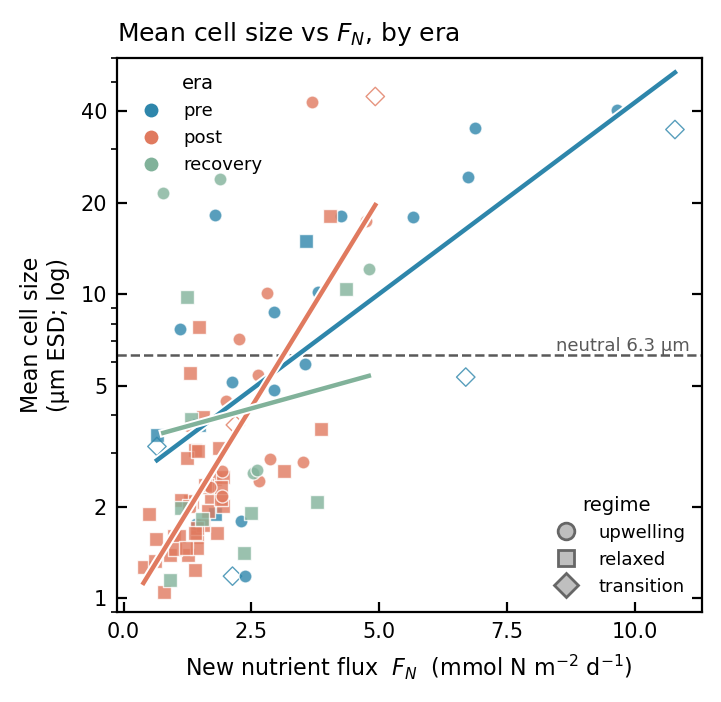

era          n  OLSslope   intcpt     rho         p
all         94    0.1620   0.1859   0.574   1.5e-09
pre         23    0.1258   0.3718   0.712   0.00014
post        57    0.2741  -0.0566   0.707   7.9e-10
recovery    14    0.0466   0.5076   0.160      0.58


In [4]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 pre-step (Fig-1 styling) — Mean cell size (MCS, µm) vs F_N by era.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
REG_MK  = {'upwelling': 'o', 'relaxed': 's', 'transition': 'D'}
UM_TICKS = [1, 2, 5, 10, 20, 40]
HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
PICO_UM, NANO_UM, MICRO_UM = 0.63, 6.3, 63.0      # Sieburth geomeans; neutral = 6.3 µm
FNCOL = 'FN_mmolN_m2_d'

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['mcs_um'] = 10.0 ** df['size_centroid']
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['mcs_um', FNCOL]).copy()
d['regime_adjusted'] = (d['regime_adjusted'].fillna('unknown')
                        if 'regime_adjusted' in d else 'unknown')

fig, ax = plt.subplots(figsize=(3.7, 3.6))
fig.subplots_adjust(left=0.17, right=0.96, top=0.92, bottom=0.15)
for e in ['pre', 'post', 'recovery']:
    s = d[d.era == e]
    for r, sr in s.groupby('regime_adjusted'):
        m = REG_MK.get(r, 'x')
        face = 'none' if r == 'transition' else ERA_COL[e]
        edge = ERA_COL[e] if r == 'transition' else 'white'
        ax.scatter(sr[FNCOL], sr.mcs_um, marker=m, s=22, alpha=0.8,
                   facecolor=face, edgecolor=edge, linewidth=0.5, zorder=3)
    if len(s) >= 8:
        b = np.polyfit(s[FNCOL], np.log10(s.mcs_um), 1)
        xx = np.linspace(s[FNCOL].min(), s[FNCOL].max(), 50)
        ax.plot(xx, 10.0 ** np.polyval(b, xx), color=ERA_COL[e], lw=1.6,
                zorder=5, path_effects=HALO)

ax.axhline(NANO_UM, color='0.35', ls='--', lw=0.9, zorder=2)
ax.text(0.99, NANO_UM, 'neutral 6.3 µm ', transform=ax.get_yaxis_transform(),
        ha='right', va='bottom', fontsize=6.5, color='0.35')
for y in (PICO_UM, MICRO_UM):
    ax.axhline(y, color='0.82', lw=0.6, zorder=1)

ax.set_yscale('log'); ax.set_yticks(UM_TICKS); ax.set_yticklabels(UM_TICKS)
ax.set_ylim(0.9, 60)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_ylabel('Mean cell size\n(µm ESD; log)', fontsize=8)
ax.set_xlabel('New nutrient flux  $F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
ax.set_title('Mean cell size vs $F_N$, by era', loc='left', fontsize=9)

eh = [Line2D([0], [0], marker='o', color='w', markerfacecolor=ERA_COL[e],
      markersize=6, label=e) for e in ['pre', 'post', 'recovery']]
rh = [Line2D([0], [0], marker=m, color='0.4', markerfacecolor='0.75', linestyle='',
      markersize=6, label=r) for r, m in REG_MK.items()]
leg1 = ax.legend(handles=eh, title='era', loc='upper left', frameon=False,
                 fontsize=6.5, title_fontsize=7)
ax.add_artist(leg1)
ax.legend(handles=rh, title='regime', loc='lower right', frameon=False,
          fontsize=6.5, title_fontsize=7)
plt.show()

print(f"{'era':9s} {'n':>4s} {'OLSslope':>9s} {'intcpt':>8s} {'rho':>7s} {'p':>9s}")
for e in ['all', 'pre', 'post', 'recovery']:
    s = d if e == 'all' else d[d.era == e]
    rho, p = spearmanr(s[FNCOL], s.mcs_um)
    b = np.polyfit(s[FNCOL], np.log10(s.mcs_um), 1)
    print(f"{e:9s} {len(s):>4d} {b[0]:>9.4f} {b[1]:>8.4f} {rho:>7.3f} {p:>9.2g}")

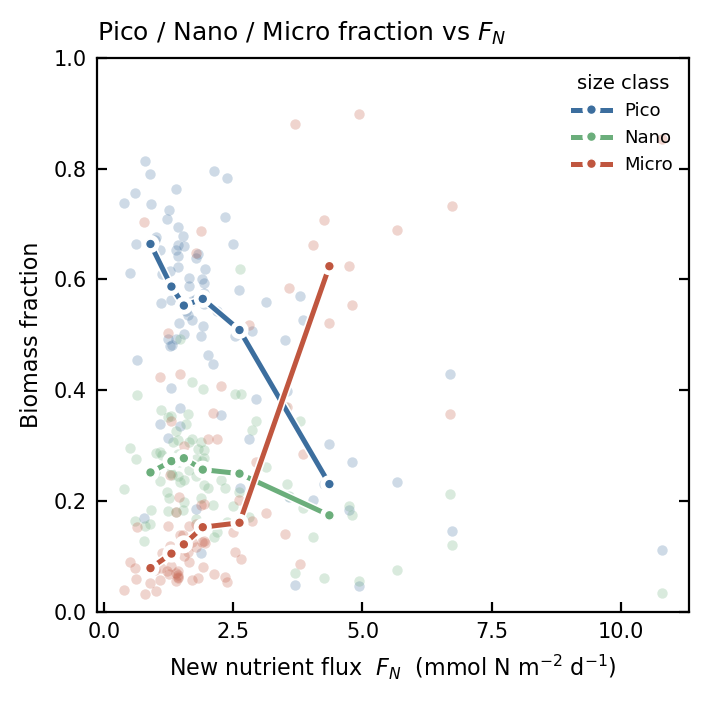

                Pico_frac  Nano_frac  Micro_frac
fn_bin                                          
(0.388, 1.172]      0.664      0.252       0.079
(1.172, 1.429]      0.587      0.272       0.105
(1.429, 1.745]      0.553      0.278       0.122
(1.745, 2.13]       0.565      0.257       0.153
(2.13, 3.527]       0.509      0.250       0.161
(3.527, 10.79]      0.231      0.175       0.624


In [5]:
%config InlineBackend.figure_format = 'retina'
# Companion (Fig-1 styling) — P/N/M biomass fraction vs F_N. Panel 2 design still open.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from cariaco_obs import DEFAULT_CSV_PATH

HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
FNCOL = 'FN_mmolN_m2_d'
BINS = [('Pico', 'pico_mmolN', '#3C6E9E'),
        ('Nano', 'nano_mmolN', '#6BAE7B'),
        ('Micro', 'micro_mmolN', '#C0563F')]
cols = [c for _, c, _ in BINS]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d = df.dropna(subset=cols + [FNCOL]).copy()
tot = d[cols].sum(axis=1)
for name, c, _ in BINS:
    d[name + '_frac'] = d[c] / tot
d['fn_bin'] = pd.qcut(d[FNCOL], 6, duplicates='drop')
centers = d.groupby('fn_bin', observed=True)[FNCOL].median()

fig, ax = plt.subplots(figsize=(3.7, 3.6))
fig.subplots_adjust(left=0.16, right=0.96, top=0.92, bottom=0.15)
for name, c, col in BINS:
    ax.scatter(d[FNCOL], d[name + '_frac'], s=14, color=col, alpha=0.25, lw=0, zorder=2)
    med = d.groupby('fn_bin', observed=True)[name + '_frac'].median()
    ax.plot(centers.values, med.values, color=col, lw=1.8, marker='o', ms=3.5,
            mec='white', mew=0.5, zorder=5, path_effects=HALO, label=name)

ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_ylabel('Biomass fraction', fontsize=8)
ax.set_xlabel('New nutrient flux  $F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
ax.set_title('Pico / Nano / Micro fraction vs $F_N$', loc='left', fontsize=9)
ax.legend(title='size class', frameon=False, fontsize=6.5, title_fontsize=7, loc='upper right')
plt.show()

print(d.groupby('fn_bin', observed=True)[[b[0] + '_frac' for b in BINS]].median().round(3))

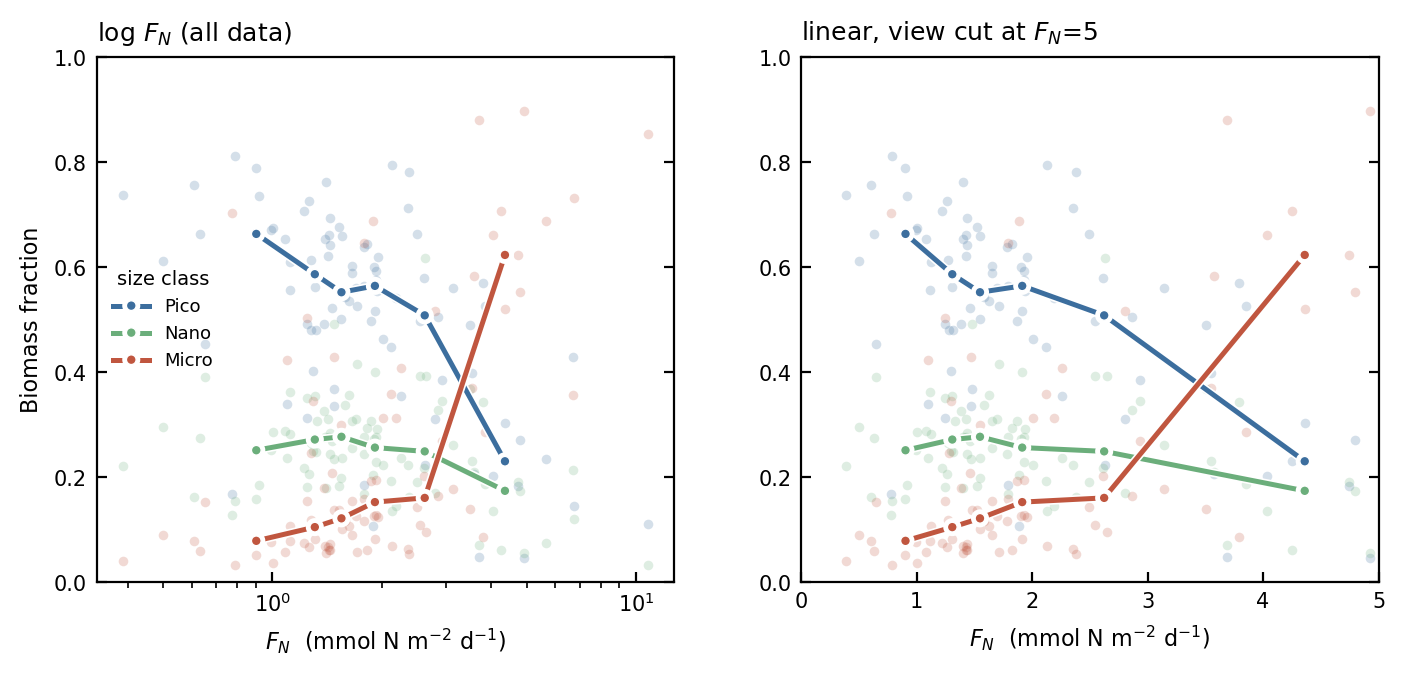

In [6]:
%config InlineBackend.figure_format = 'retina'
# Test — P/N/M fraction vs F_N:  LEFT log-x (all data)  |  RIGHT linear, view cut at F_N=5.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from cariaco_obs import DEFAULT_CSV_PATH

HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
FNCOL = 'FN_mmolN_m2_d'
BINS = [('Pico', 'pico_mmolN', '#3C6E9E'),
        ('Nano', 'nano_mmolN', '#6BAE7B'),
        ('Micro', 'micro_mmolN', '#C0563F')]
cols = [c for _, c, _ in BINS]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d = df.dropna(subset=cols + [FNCOL]).copy()
tot = d[cols].sum(axis=1)
for name, c, _ in BINS:
    d[name + '_frac'] = d[c] / tot
d['fn_bin'] = pd.qcut(d[FNCOL], 6, duplicates='drop')
centers = d.groupby('fn_bin', observed=True)[FNCOL].median()
meds = {name: d.groupby('fn_bin', observed=True)[name + '_frac'].median() for name, _, _ in BINS}

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.5))
fig.subplots_adjust(left=0.09, right=0.98, top=0.90, bottom=0.15, wspace=0.22)
for ax, mode in zip(axes, ['log', 'cut']):
    for name, c, col in BINS:
        ax.scatter(d[FNCOL], d[name + '_frac'], s=12, color=col, alpha=0.22, lw=0, zorder=2)
        ax.plot(centers.values, meds[name].values, color=col, lw=1.8, marker='o', ms=3.5,
                mec='white', mew=0.5, zorder=5, path_effects=HALO, label=name)
    ax.set_ylim(0, 1)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
    ax.set_xlabel('$F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
    if mode == 'log':
        ax.set_xscale('log')
        ax.set_title('log $F_N$ (all data)', loc='left', fontsize=9)
        ax.set_ylabel('Biomass fraction', fontsize=8)
    else:
        ax.set_xlim(0, 5)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.set_title('linear, view cut at $F_N$=5', loc='left', fontsize=9)
axes[0].legend(title='size class', frameon=False, fontsize=6.5, title_fontsize=7, loc='center left')
plt.show()

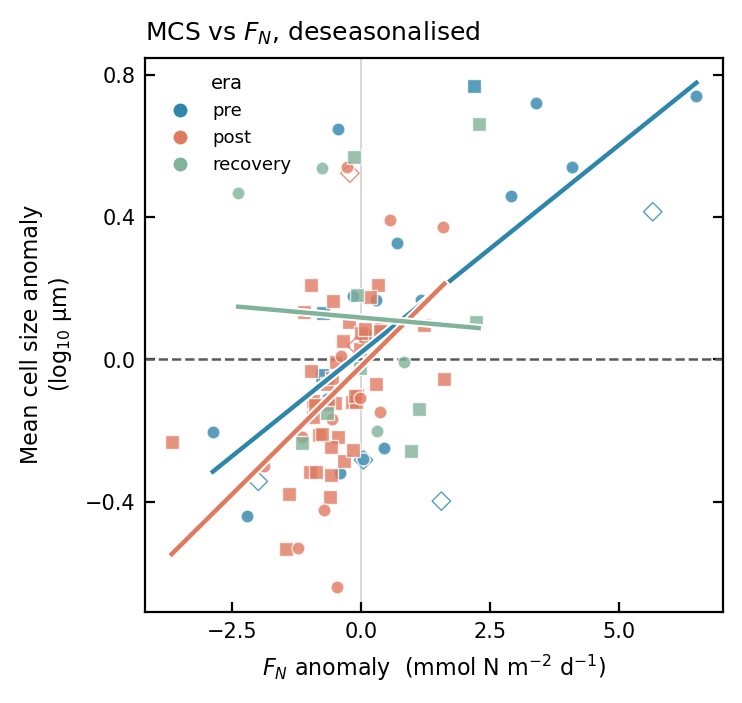

era          n mean_dMCS    slope     rho         p   (deseasonalised)
all         94   -0.0000   0.1151   0.497   3.4e-07
pre         23    0.1160   0.1169   0.625    0.0014
post        57   -0.0751   0.1441   0.583   1.9e-06
recovery    14    0.1150  -0.0129  -0.015      0.96


In [7]:
%config InlineBackend.figure_format = 'retina'
# Test — MCS vs F_N DESEASONALISED (both axes = anomaly vs pooled monthly climatology).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
REG_MK  = {'upwelling': 'o', 'relaxed': 's', 'transition': 'D'}
HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
FNCOL = 'FN_mmolN_m2_d'

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['mcs_log'] = df['size_centroid']                       # log10 MCS (µm)
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['mcs_log', FNCOL]).copy()
d['mo'] = d['date'].dt.month
d['mcs_anom'] = d['mcs_log'] - d.groupby('mo')['mcs_log'].transform('mean')   # pooled climatology
d['fn_anom']  = d[FNCOL]     - d.groupby('mo')[FNCOL].transform('mean')
d['regime_adjusted'] = (d['regime_adjusted'].fillna('unknown')
                        if 'regime_adjusted' in d else 'unknown')

fig, ax = plt.subplots(figsize=(3.7, 3.6))
fig.subplots_adjust(left=0.18, right=0.96, top=0.92, bottom=0.15)
for e in ['pre', 'post', 'recovery']:
    s = d[d.era == e]
    for r, sr in s.groupby('regime_adjusted'):
        m = REG_MK.get(r, 'x')
        face = 'none' if r == 'transition' else ERA_COL[e]
        edge = ERA_COL[e] if r == 'transition' else 'white'
        ax.scatter(sr.fn_anom, sr.mcs_anom, marker=m, s=22, alpha=0.8,
                   facecolor=face, edgecolor=edge, linewidth=0.5, zorder=3)
    if len(s) >= 8:
        b = np.polyfit(s.fn_anom, s.mcs_anom, 1)
        xx = np.linspace(s.fn_anom.min(), s.fn_anom.max(), 50)
        ax.plot(xx, np.polyval(b, xx), color=ERA_COL[e], lw=1.6, zorder=5, path_effects=HALO)

ax.axhline(0, color='0.35', ls='--', lw=0.9, zorder=2)
ax.axvline(0, color='0.82', lw=0.6, zorder=1)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5)); ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_ylabel('Mean cell size anomaly\n(log$_{10}$ µm)', fontsize=8)
ax.set_xlabel('$F_N$ anomaly  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
ax.set_title('MCS vs $F_N$, deseasonalised', loc='left', fontsize=9)
eh = [Line2D([0], [0], marker='o', color='w', markerfacecolor=ERA_COL[e], markersize=6, label=e)
      for e in ['pre', 'post', 'recovery']]
ax.legend(handles=eh, title='era', loc='upper left', frameon=False, fontsize=6.5, title_fontsize=7)
plt.show()

print(f"{'era':9s} {'n':>4s} {'mean_dMCS':>9s} {'slope':>8s} {'rho':>7s} {'p':>9s}   (deseasonalised)")
for e in ['all', 'pre', 'post', 'recovery']:
    s = d if e == 'all' else d[d.era == e]
    rho, p = spearmanr(s.fn_anom, s.mcs_anom)
    b = np.polyfit(s.fn_anom, s.mcs_anom, 1)
    print(f"{e:9s} {len(s):>4d} {s.mcs_anom.mean():>9.4f} {b[0]:>8.4f} {rho:>7.3f} {p:>9.2g}")

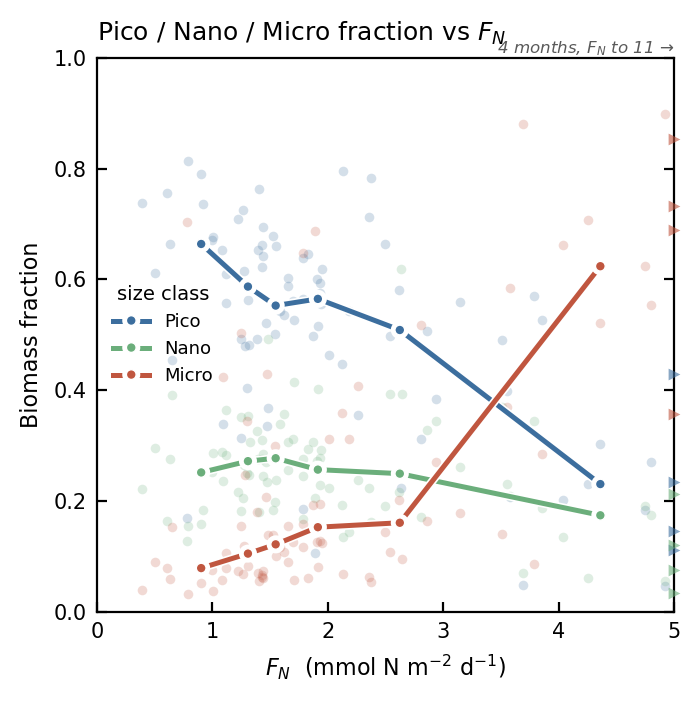

off-scale (F_N>5.0): n=4; median P/N/M = 0.19/0.10/0.71


In [8]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 Panel 2 draft — P/N/M fraction vs F_N, linear view cut at F_N=5,
# off-scale months flagged as edge chevrons + a count annotation.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from cariaco_obs import DEFAULT_CSV_PATH

HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
FNCOL = 'FN_mmolN_m2_d'
XCUT = 5.0
BINS = [('Pico', 'pico_mmolN', '#3C6E9E'),
        ('Nano', 'nano_mmolN', '#6BAE7B'),
        ('Micro', 'micro_mmolN', '#C0563F')]
cols = [c for _, c, _ in BINS]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d = df.dropna(subset=cols + [FNCOL]).copy()
tot = d[cols].sum(axis=1)
for name, c, _ in BINS:
    d[name + '_frac'] = d[c] / tot
d['fn_bin'] = pd.qcut(d[FNCOL], 6, duplicates='drop')
centers = d.groupby('fn_bin', observed=True)[FNCOL].median()
meds = {name: d.groupby('fn_bin', observed=True)[name + '_frac'].median() for name, _, _ in BINS}

inb, oob = d[d[FNCOL] <= XCUT], d[d[FNCOL] > XCUT]

fig, ax = plt.subplots(figsize=(3.7, 3.6))
fig.subplots_adjust(left=0.16, right=0.94, top=0.92, bottom=0.15)
for name, c, col in BINS:
    ax.scatter(inb[FNCOL], inb[name + '_frac'], s=12, color=col, alpha=0.22, lw=0, zorder=2)
    ax.scatter(np.full(len(oob), XCUT), oob[name + '_frac'], marker='>', s=18,
               color=col, alpha=0.6, lw=0, zorder=6, clip_on=False)          # off-scale flag
    ax.plot(centers.values, meds[name].values, color=col, lw=1.8, marker='o', ms=3.5,
            mec='white', mew=0.5, zorder=5, path_effects=HALO, label=name)

ax.set_xlim(0, XCUT); ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_xlabel('$F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
ax.set_ylabel('Biomass fraction', fontsize=8)
ax.set_title('Pico / Nano / Micro fraction vs $F_N$', loc='left', fontsize=9)
ax.text(XCUT, 1.0, f' {len(oob)} months, $F_N$ to {d[FNCOL].max():.0f} →',
        ha='right', va='bottom', fontsize=6, color='0.35', style='italic')
ax.legend(title='size class', frameon=False, fontsize=6.5, title_fontsize=7, loc='center left')
plt.show()

print(f"off-scale (F_N>{XCUT}): n={len(oob)}; median P/N/M = "
      f"{oob['Pico_frac'].median():.2f}/{oob['Nano_frac'].median():.2f}/{oob['Micro_frac'].median():.2f}")

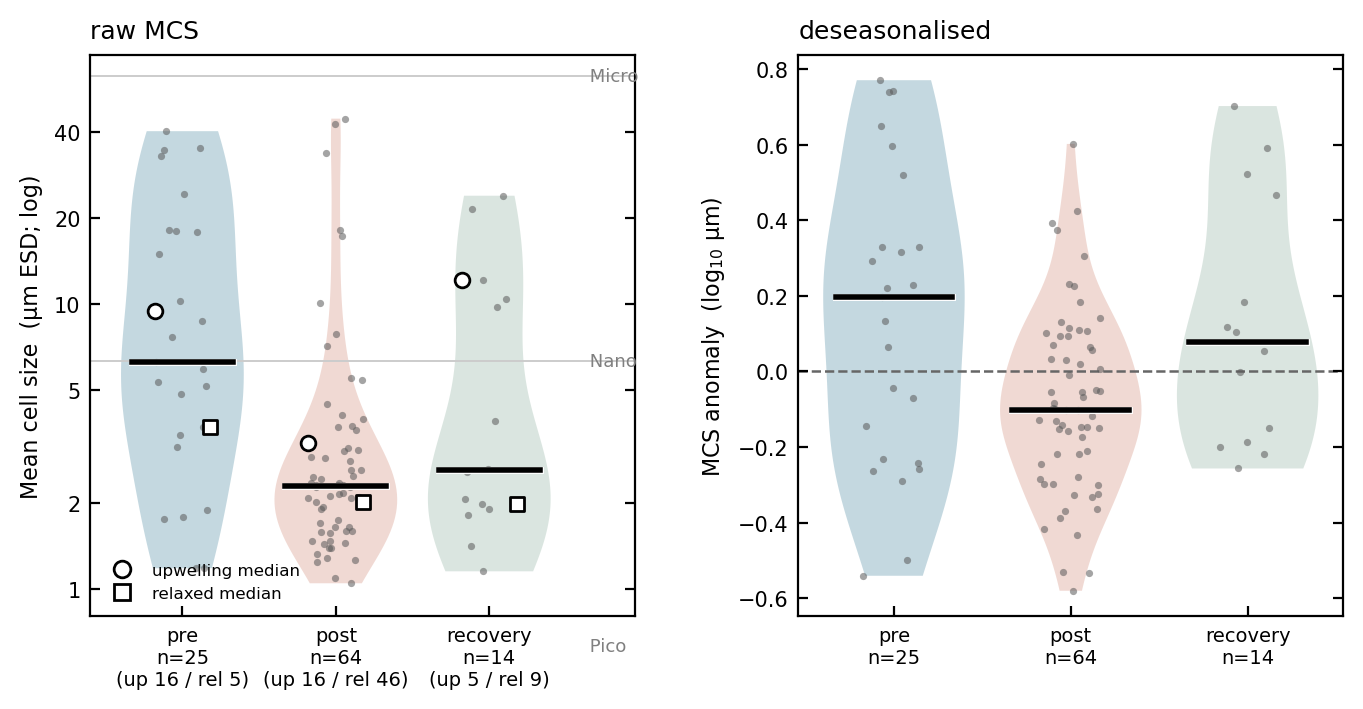

RAW (log10 µm; µm in parens):
  pre       n= 25  median=+0.796 (6.3 µm)  up=+0.975  rel=+0.569
  post      n= 64  median=+0.361 (2.3 µm)  up=+0.512  rel=+0.304
  recovery  n= 14  median=+0.416 (2.6 µm)  up=+1.082  rel=+0.297
DESEASONALISED (log10 µm anomaly):
  pre       n= 25  median=+0.196  mean=+0.142
  post      n= 64  median=-0.101  mean=-0.082
  recovery  n= 14  median=+0.079  mean=+0.123


In [9]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 Panel 1 test — MCS era violin: LEFT raw µm (with regime split, option c) | RIGHT deseasonalised.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
UM_TICKS = [1, 2, 5, 10, 20, 40]
GEOMEANS = {'Pico': 0.63, 'Nano': 6.3, 'Micro': 63.0}
HALO = [pe.withStroke(linewidth=2.5, foreground='white')]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['size_centroid']).copy()                 # centroid = log10 MCS (µm)
d['mo'] = d['date'].dt.month
d['mcs_anom'] = d['size_centroid'] - d.groupby('mo')['size_centroid'].transform('mean')
d['regime_adjusted'] = (d['regime_adjusted'].fillna('unknown')
                        if 'regime_adjusted' in d else 'unknown')

fig, (axR, axA) = plt.subplots(1, 2, figsize=(7.2, 3.9))
fig.subplots_adjust(left=0.10, right=0.97, top=0.90, bottom=0.18, wspace=0.30)

def soften_violins(ax):
    for v in ax.collections:
        v.set_alpha(0.30); v.set_edgecolor('none')

# ---------- LEFT: raw MCS (log10 µm), regime split ----------
sns.violinplot(data=d, x='era', y='size_centroid', order=ERA_ORDER, hue='era',
               palette=ERA_COL, legend=False, inner=None, cut=0, linewidth=0.8, ax=axR)
soften_violins(axR)
sns.stripplot(data=d, x='era', y='size_centroid', order=ERA_ORDER, color='0.35',
              size=2.6, alpha=0.55, jitter=0.18, ax=axR)
for i, e in enumerate(ERA_ORDER):
    s = d[d.era == e]
    axR.plot([i - 0.33, i + 0.33], [s.size_centroid.median()] * 2, color='black', lw=2.0,
             zorder=6, path_effects=HALO)
    for r, dx, mk in [('upwelling', -0.18, 'o'), ('relaxed', 0.18, 's')]:
        sr = s[s.regime_adjusted == r]
        if len(sr):
            axR.scatter(i + dx, sr.size_centroid.median(), marker=mk, s=28, facecolor='white',
                        edgecolor='black', linewidth=1.0, zorder=7)
for name, um in GEOMEANS.items():
    y = np.log10(um)
    axR.axhline(y, color='0.8', lw=0.7, zorder=1)
    axR.text(2.62, y, f' {name}', va='center', ha='left', fontsize=6.5, color='0.5')
axR.set_xlim(-0.6, 2.95)
axR.set_yticks([np.log10(u) for u in UM_TICKS]); axR.set_yticklabels(UM_TICKS)
axR.set_ylim(np.log10(0.8), np.log10(75))
axR.set_ylabel('Mean cell size  (µm ESD; log)', fontsize=8); axR.set_xlabel('')
axR.set_title('raw MCS', loc='left', fontsize=9)
axR.tick_params(top=False, right=True, direction='in', labelsize=7.5)
labs = []
for e in ERA_ORDER:
    s = d[d.era == e]
    nu = (s.regime_adjusted == 'upwelling').sum(); nr = (s.regime_adjusted == 'relaxed').sum()
    labs.append(f'{e}\nn={len(s)}\n(up {nu} / rel {nr})')
axR.set_xticks(range(3)); axR.set_xticklabels(labs, fontsize=7)
axR.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
                    markeredgecolor='black', label='upwelling median', markersize=6),
                    Line2D([0], [0], marker='s', color='w', markerfacecolor='white',
                    markeredgecolor='black', label='relaxed median', markersize=6)],
           loc='lower left', frameon=False, fontsize=6)

# ---------- RIGHT: deseasonalised anomaly ----------
sns.violinplot(data=d, x='era', y='mcs_anom', order=ERA_ORDER, hue='era',
               palette=ERA_COL, legend=False, inner=None, cut=0, linewidth=0.8, ax=axA)
soften_violins(axA)
sns.stripplot(data=d, x='era', y='mcs_anom', order=ERA_ORDER, color='0.35',
              size=2.6, alpha=0.55, jitter=0.18, ax=axA)
for i, e in enumerate(ERA_ORDER):
    s = d[d.era == e]
    axA.plot([i - 0.33, i + 0.33], [s.mcs_anom.median()] * 2, color='black', lw=2.0,
             zorder=6, path_effects=HALO)
axA.axhline(0, color='0.4', ls='--', lw=0.9, zorder=1)
axA.set_ylabel('MCS anomaly  (log$_{10}$ µm)', fontsize=8); axA.set_xlabel('')
axA.set_title('deseasonalised', loc='left', fontsize=9)
axA.tick_params(top=False, right=True, direction='in', labelsize=7.5)
axA.set_xticks(range(3))
axA.set_xticklabels([f'{e}\nn={len(d[d.era == e])}' for e in ERA_ORDER], fontsize=7)
plt.show()

print("RAW (log10 µm; µm in parens):")
for e in ERA_ORDER:
    s = d[d.era == e]
    up = s[s.regime_adjusted == 'upwelling'].size_centroid.median()
    rel = s[s.regime_adjusted == 'relaxed'].size_centroid.median()
    print(f"  {e:9s} n={len(s):3d}  median={s.size_centroid.median():+.3f} "
          f"({10 ** s.size_centroid.median():.1f} µm)  up={up:+.3f}  rel={rel:+.3f}")
print("DESEASONALISED (log10 µm anomaly):")
for e in ERA_ORDER:
    s = d[d.era == e]
    print(f"  {e:9s} n={len(s):3d}  median={s.mcs_anom.median():+.3f}  mean={s.mcs_anom.mean():+.3f}")

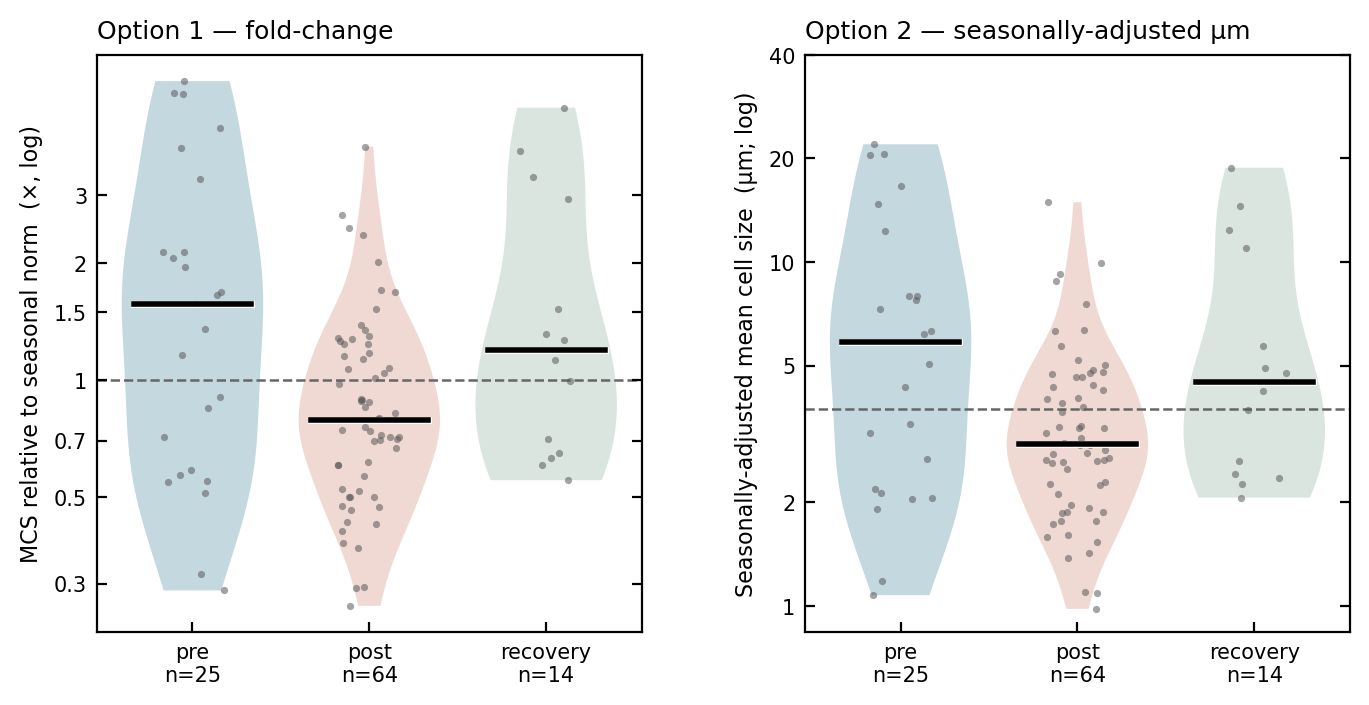

overall-mean MCS = 3.7 µm  (log10 +0.572)
  pre       fold-change=1.57x   adjusted=5.9 µm
  post      fold-change=0.79x   adjusted=3.0 µm
  recovery  fold-change=1.20x   adjusted=4.5 µm


In [10]:
%config InlineBackend.figure_format = 'retina'
# Deseasonalised MCS violin — two readable y-axes: LEFT fold-change (×) | RIGHT seasonally-adjusted µm.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
RATIO_TICKS = [0.3, 0.5, 0.7, 1, 1.5, 2, 3]
UM_TICKS = [1, 2, 5, 10, 20, 40]
HALO = [pe.withStroke(linewidth=2.5, foreground='white')]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['size_centroid']).copy()                  # log10 MCS (µm)
d['mo'] = d['date'].dt.month
d['mcs_anom'] = d['size_centroid'] - d.groupby('mo')['size_centroid'].transform('mean')
GM = d['size_centroid'].mean()                                  # overall-mean log10 MCS
d['mcs_adj'] = d['mcs_anom'] + GM                               # seasonally-adjusted log10 µm

def soften(ax):
    for v in ax.collections:
        v.set_alpha(0.30); v.set_edgecolor('none')

def violin(ax, ycol, title):
    sns.violinplot(data=d, x='era', y=ycol, order=ERA_ORDER, hue='era',
                   palette=ERA_COL, legend=False, inner=None, cut=0, linewidth=0.8, ax=ax)
    soften(ax)
    sns.stripplot(data=d, x='era', y=ycol, order=ERA_ORDER, color='0.35',
                  size=2.6, alpha=0.55, jitter=0.18, ax=ax)
    for i, e in enumerate(ERA_ORDER):
        s = d[d.era == e]
        ax.plot([i - 0.33, i + 0.33], [s[ycol].median()] * 2, color='black', lw=2.0,
                zorder=6, path_effects=HALO)
    ax.set_xticks(range(3))
    ax.set_xticklabels([f'{e}\nn={len(d[d.era == e])}' for e in ERA_ORDER], fontsize=7.5)
    ax.set_xlabel(''); ax.set_title(title, loc='left', fontsize=9)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.9))
fig.subplots_adjust(left=0.10, right=0.97, top=0.90, bottom=0.16, wspace=0.30)

violin(ax1, 'mcs_anom', 'Option 1 — fold-change')
ax1.axhline(0, color='0.4', ls='--', lw=0.9, zorder=1)         # 1.0x baseline
ax1.set_yticks([np.log10(r) for r in RATIO_TICKS]); ax1.set_yticklabels(RATIO_TICKS)
ax1.set_ylabel('MCS relative to seasonal norm  (×, log)', fontsize=8)

violin(ax2, 'mcs_adj', 'Option 2 — seasonally-adjusted µm')
ax2.axhline(GM, color='0.4', ls='--', lw=0.9, zorder=1)        # overall-mean baseline
ax2.set_yticks([np.log10(u) for u in UM_TICKS]); ax2.set_yticklabels(UM_TICKS)
ax2.set_ylabel('Seasonally-adjusted mean cell size  (µm; log)', fontsize=8)

plt.show()

print(f"overall-mean MCS = {10 ** GM:.1f} µm  (log10 {GM:+.3f})")
for e in ERA_ORDER:
    a = d[d.era == e]['mcs_anom'].median()
    print(f"  {e:9s} fold-change={10 ** a:.2f}x   adjusted={10 ** (a + GM):.1f} µm")

In [11]:
# Era-contrast statistics for the MCS violin (printout only; for methods / rebuttal).
import numpy as np, pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['size_centroid']).copy()
d['mo'] = d['date'].dt.month
d['mcs_anom'] = d['size_centroid'] - d.groupby('mo')['size_centroid'].transform('mean')

def cliffs_delta(x, y):
    x, y = np.asarray(x), np.asarray(y)
    return np.sign(x[:, None] - y[None, :]).mean()          # + => first group larger

def holm(pvals):
    pvals = np.asarray(pvals); m = len(pvals); order = np.argsort(pvals)
    adj = np.empty(m); run = 0.0
    for rank, idx in enumerate(order):
        run = max(run, (m - rank) * pvals[idx]); adj[idx] = min(run, 1.0)
    return adj

def boot_fold_ci(a, b, n=5000, seed=0):
    rng = np.random.default_rng(seed); a, b = np.asarray(a), np.asarray(b)
    diffs = [np.median(rng.choice(a, a.size)) - np.median(rng.choice(b, b.size)) for _ in range(n)]
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return 10 ** lo, 10 ** hi

PAIRS = [('pre', 'post'), ('pre', 'recovery'), ('post', 'recovery')]

def run_block(col, label):
    groups = [d.loc[d.era == e, col].values for e in ERA_ORDER]
    H, pk = kruskal(*groups)
    print(f"\n=== {label} ===")
    print(f"Kruskal-Wallis (3 eras): H={H:.2f}  p={pk:.2g}")
    praw = [mannwhitneyu(d.loc[d.era == a, col], d.loc[d.era == b, col],
                         alternative='two-sided')[1] for a, b in PAIRS]
    pholm = holm(praw)
    print(f"{'pair':15s} {'n1,n2':>8s} {'p_raw':>8s} {'p_holm':>8s} {'Cliff_d':>8s} {'fold(med)':>10s} {'95% CI':>15s}")
    for (a, b), pr, ph in zip(PAIRS, praw, pholm):
        x, y = d.loc[d.era == a, col].values, d.loc[d.era == b, col].values
        dlt = cliffs_delta(x, y)
        fold = 10 ** (np.median(x) - np.median(y)); lo, hi = boot_fold_ci(x, y)
        print(f"{a+' vs '+b:15s} {f'{len(x)},{len(y)}':>8s} {pr:>8.2g} {ph:>8.2g} "
              f"{dlt:>+8.2f} {fold:>9.2f}x [{lo:.2f}, {hi:.2f}]")

run_block('mcs_anom', 'MONTHLY - deseasonalised MCS anomaly')
run_block('size_centroid', 'MONTHLY - raw MCS (log10 um)')

print("\n=== ANNUAL-MEAN robustness (more independent samples) ===")
for col, lab in [('mcs_anom', 'deseasonalised'), ('size_centroid', 'raw')]:
    ann = d.assign(yr=d.date.dt.year).groupby('yr').agg(val=(col, 'mean')).reset_index()
    ann['era'] = np.where(ann.yr < 2005, 'pre', np.where(ann.yr < 2014, 'post', 'recovery'))
    g = [ann.loc[ann.era == e, 'val'].values for e in ERA_ORDER]
    H, pk = kruskal(*g)
    pp = mannwhitneyu(g[0], g[1], alternative='two-sided')[1]
    print(f"  {lab:14s} years pre/post/rec = {len(g[0])}/{len(g[1])}/{len(g[2])}  "
          f"KW p={pk:.2g}  pre-vs-post MW p={pp:.2g}")

print("\nNote: monthly values are temporally autocorrelated -> p-values are optimistic; "
      "weight the Cliff's delta + bootstrap fold-change CIs. The annual-mean block is the "
      "independence cross-check (recovery years are few).")


=== MONTHLY - deseasonalised MCS anomaly ===
Kruskal-Wallis (3 eras): H=8.56  p=0.014
pair               n1,n2    p_raw   p_holm  Cliff_d  fold(med)          95% CI
pre vs post        25,64    0.011    0.032    +0.35      1.98x [0.92, 2.72]
pre vs recovery    25,14     0.85     0.85    +0.04      1.31x [0.51, 2.55]
post vs recovery    64,14    0.052      0.1    -0.33      0.66x [0.34, 1.21]

=== MONTHLY - raw MCS (log10 um) ===
Kruskal-Wallis (3 eras): H=13.49  p=0.0012
pair               n1,n2    p_raw   p_holm  Cliff_d  fold(med)          95% CI
pre vs post        25,64  0.00021  0.00064    +0.51      2.72x [1.72, 7.65]
pre vs recovery    25,14     0.16     0.31    +0.28      2.40x [0.55, 6.77]
post vs recovery    64,14      0.3     0.31    -0.18      0.88x [0.21, 1.22]

=== ANNUAL-MEAN robustness (more independent samples) ===
  deseasonalised years pre/post/rec = 5/7/3  KW p=0.067  pre-vs-post MW p=0.15
  raw            years pre/post/rec = 5/7/3  KW p=0.0035  pre-vs-post MW p=0.0

In [2]:
# Fig 3 — pre+recovery FOLD exploration (numeric, decision-grade). Run from code/.
# Q: is treating pre+recovery as one "fish-present" era defensible, and on what basis?
import numpy as np, pandas as pd
from scipy.stats import mannwhitneyu
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era']  = np.where(df.date.dt.year < 2005, 'pre',
             np.where(df.date.dt.year < 2014, 'post', 'recovery'))
df['fish'] = np.where(df.era == 'post', 'absent', 'present')      # pre+recovery = fish-present
reg = 'regime_adjusted' if 'regime_adjusted' in df.columns else 'upwelling'
df[reg] = df[reg].astype('object').fillna('unknown')
df['mcs_um'] = 10.0 ** df['size_centroid']
binc = ['pico_mmolN', 'nano_mmolN', 'micro_mmolN']
tot = df[binc].sum(axis=1)
for b in binc: df[b.split('_')[0] + '_frac'] = df[b] / tot

ERAS = ['pre', 'post', 'recovery']
GRP  = [(e, df[df.era == e]) for e in ERAS] + [('pre+recovery', df[df.fish == 'present'])]
has  = lambda c: c in df.columns

def cliffs(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    x, y = x[~np.isnan(x)], y[~np.isnan(y)]
    return np.nan if (len(x)==0 or len(y)==0) else np.sign(x[:,None]-y[None,:]).mean()
def mw(x, y):
    x, y = pd.Series(x).dropna(), pd.Series(y).dropna()
    return np.nan if (len(x)<3 or len(y)<3) else mannwhitneyu(x, y, alternative='two-sided')[1]
def m(s):
    s = pd.Series(s).dropna(); return s.median() if len(s) else np.nan

print("=== A. Coverage & regime mix (months with size_centroid) — explains the raw-median confound ===")
sz = df.dropna(subset=['size_centroid'])
print(f"{'group':14s} {'n':>4s} {'up':>4s} {'rel':>4s} {'trans':>6s} {'%up':>5s}")
for name, g0 in GRP:
    g = g0.dropna(subset=['size_centroid']); vc = g[reg].value_counts()
    up, rel, tr = vc.get('upwelling',0), vc.get('relaxed',0), vc.get('transition',0)
    print(f"{name:14s} {len(g):>4d} {up:>4d} {rel:>4d} {tr:>6d} {(100*up/len(g) if len(g) else 0):>4.0f}%")

def er_table(col, label):
    if not has(col): print(f"\n--- {label}: column '{col}' absent ---"); return
    print(f"\n--- {label}  median [n]  (all | upwelling | relaxed) ---")
    print(f"{'group':14s} {'all':>13s} {'upwelling':>13s} {'relaxed':>13s}")
    for name, g in GRP:
        out = []
        for r in ['all','upwelling','relaxed']:
            s = (g if r=='all' else g[g[reg]==r])[col].dropna()
            out.append(f"{m(s):6.2f} [{len(s):>2d}]" if len(s) else f"{'--':>6s} [ 0]")
        print(f"{name:14s} {out[0]:>13s} {out[1]:>13s} {out[2]:>13s}")

er_table('mcs_um',            'MCS (µm)')
er_table('temp_50m',          'temp_50m (°C)  [recovery warm? -> explains pooled drop]')
er_table('FN_mmolN_m2_d',     'F_N (mmol N m-2 d-1)  [recovery = post-like supply?]')
er_table('micro_frac',        'Micro fraction')
er_table('nano_frac',         'Nano fraction')
er_table('pico_frac',         'Pico fraction')
er_table('zoo_gt200_mmolN',   'Zoo>200 (top-down tell: post HIGH despite low supply)')
er_table('zoo_gt500_mmolN',   'Zoo>500')
er_table('PhaeoChl_ratio',    'PhaeoChl ratio (grazing-pressure proxy)')

def fold_tests(col, label):
    if not has(col): return
    print(f"\n=== FOLD TESTS — {label} ===   (want: pre~recovery n.s.  AND  fish-present vs post sig.)")
    print(f"{'regime':10s} {'contrast':22s} {'n1,n2':>9s} {'med1':>8s} {'med2':>8s} {'MW p':>8s} {'Cliff_d':>8s}")
    for r in ['upwelling','relaxed']:
        sub = df[df[reg]==r]
        pre  = sub[sub.era=='pre'][col];      rec  = sub[sub.era=='recovery'][col]
        post = sub[sub.era=='post'][col];     fp   = sub[sub.fish=='present'][col]
        for cn, a, b in [('pre vs recovery', pre, rec),
                         ('pre vs post', pre, post),
                         ('fish-present vs post', fp, post)]:
            print(f"{r:10s} {cn:22s} {f'{a.notna().sum()},{b.notna().sum()}':>9s} "
                  f"{m(a):>8.2f} {m(b):>8.2f} {mw(a,b):>8.3g} {cliffs(a,b):>+8.2f}")

fold_tests('mcs_um',          'MCS (µm)')
fold_tests('micro_frac',      'Micro fraction')
fold_tests('zoo_gt200_mmolN', 'Zoo>200')
fold_tests('PhaeoChl_ratio',  'PhaeoChl ratio')

print("\nNote: months autocorrelated -> p's optimistic; recovery n tiny (esp. upwelling) -> lean on "
      "Cliff's d + the denser top-down proxies (zoo, PhaeoChl) where HPLC size is underpowered.")

=== A. Coverage & regime mix (months with size_centroid) — explains the raw-median confound ===
group             n   up  rel  trans   %up
pre              25   16    5      4   64%
post             64   16   46      2   25%
recovery         14    5    9      0   36%
pre+recovery     39   21   14      4   54%

--- MCS (µm)  median [n]  (all | upwelling | relaxed) ---
group                    all     upwelling       relaxed
pre                6.26 [25]     9.46 [16]     3.71 [ 5]
post               2.30 [64]     3.28 [16]     2.01 [46]
recovery           2.61 [14]    12.09 [ 5]     1.98 [ 9]
pre+recovery       5.34 [39]    10.19 [21]     2.76 [14]

--- temp_50m (°C)  [recovery warm? -> explains pooled drop]  median [n]  (all | upwelling | relaxed) ---
group                    all     upwelling       relaxed
pre              22.28 [107]    21.25 [46]    23.53 [51]
post              22.83 [99]    21.26 [30]    23.85 [65]
recovery          22.12 [22]    21.07 [11]    23.74 [11]
pre+recover

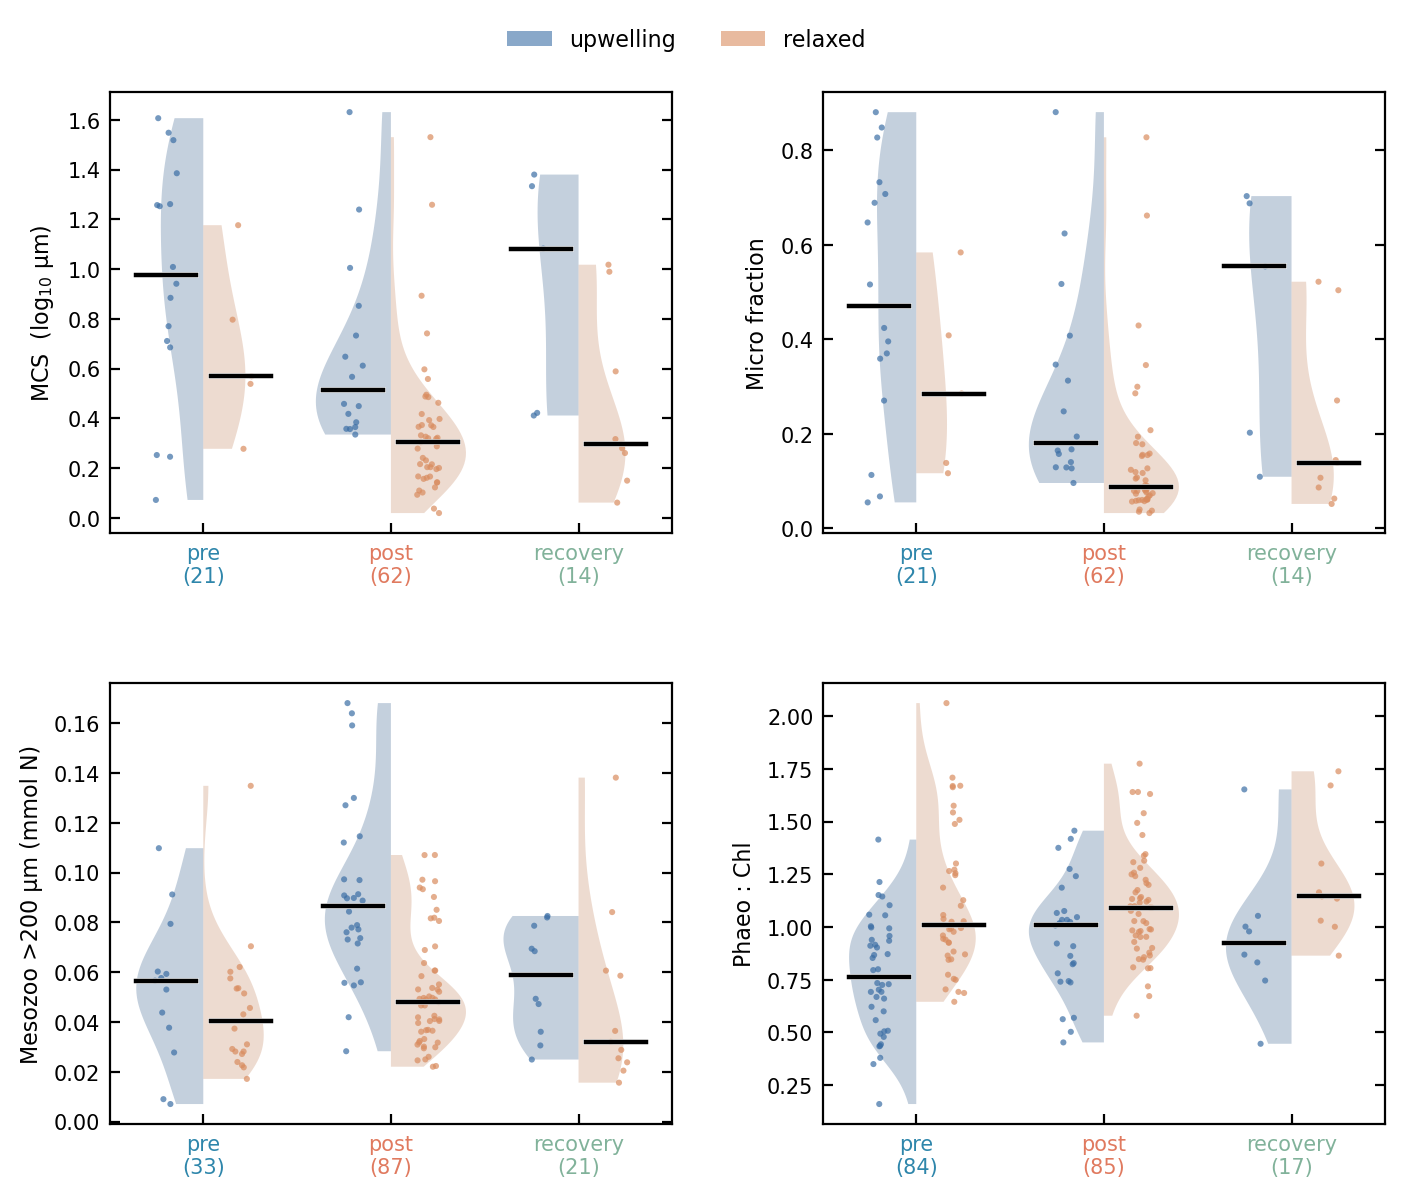

median by era × regime  (upwelling / relaxed):
  MCS  (log$_{10}$ µm)       pre 0.975/0.569 | post 0.512/0.304 | recovery 1.082/0.297
  Micro fraction             pre 0.470/0.285 | post 0.181/0.087 | recovery 0.554/0.139
  Mesozoo >200 µm (mmol N)   pre 0.057/0.040 | post 0.087/0.048 | recovery 0.059/0.032
  Phaeo : Chl                pre 0.765/1.010 | post 1.011/1.092 | recovery 0.924/1.145


In [5]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 exploration — OVERVIEW: four metrics, violins by era, SPLIT BY SEASON (regime).
# Native units; every month a strip dot (thin cells visible as dots).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
REG_ORDER = ['upwelling', 'relaxed']
REG_COL = {'upwelling': '#3B6EA5', 'relaxed': '#D98C5F'}
HALO = [pe.withStroke(linewidth=2.0, foreground='white')]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df.date.dt.year < 2005, 'pre',
            np.where(df.date.dt.year < 2014, 'post', 'recovery'))
reg = 'regime_adjusted' if 'regime_adjusted' in df.columns else 'upwelling'
df['micro_frac'] = df['micro_mmolN'] / df[['pico_mmolN','nano_mmolN','micro_mmolN']].sum(axis=1)
d = df[df[reg].isin(REG_ORDER)].copy()

METRICS = [('size_centroid',  'MCS  (log$_{10}$ µm)'),
           ('micro_frac',     'Micro fraction'),
           ('zoo_gt200_mmolN','Mesozoo >200 µm (mmol N)'),
           ('PhaeoChl_ratio', 'Phaeo : Chl')]

fig, axes = plt.subplots(2, 2, figsize=(7.2, 6.0))
fig.subplots_adjust(left=0.10, right=0.985, top=0.93, bottom=0.07, hspace=0.34, wspace=0.27)
for ax, (col, lab) in zip(axes.ravel(), METRICS):
    dd = d.dropna(subset=[col])
    sns.violinplot(data=dd, x='era', y=col, order=ERA_ORDER, hue=reg, hue_order=REG_ORDER,
                   split=True, palette=REG_COL, inner=None, cut=0, linewidth=0.6,
                   legend=False, ax=ax)
    for v in ax.collections: v.set_alpha(0.32); v.set_edgecolor('none')
    sns.stripplot(data=dd, x='era', y=col, order=ERA_ORDER, hue=reg, hue_order=REG_ORDER,
                  dodge=True, palette=REG_COL, size=2.2, alpha=0.7, jitter=0.12,
                  legend=False, ax=ax)
    for i, e in enumerate(ERA_ORDER):
        for k, r in enumerate(REG_ORDER):
            s = dd[(dd.era == e) & (dd[reg] == r)][col]
            if len(s):
                x0 = i + (-0.2 if k == 0 else 0.2)
                ax.plot([x0 - 0.16, x0 + 0.16], [s.median()]*2, color='black', lw=1.6,
                        zorder=6, path_effects=HALO)
    ax.set_xlabel(''); ax.set_ylabel(lab, fontsize=8)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
    ax.set_xticks(range(3))
    ax.set_xticklabels([f'{e}\n({len(dd[dd.era==e])})' for e in ERA_ORDER], fontsize=7.5)
    for t, e in zip(ax.get_xticklabels(), ERA_ORDER): t.set_color(ERA_COL[e])
fig.legend(handles=[Patch(facecolor=REG_COL[r], alpha=0.6, label=r) for r in REG_ORDER],
           loc='upper center', ncol=2, frameon=False, fontsize=8, bbox_to_anchor=(0.5, 1.0))
plt.show()

print("median by era × regime  (upwelling / relaxed):")
for col, lab in METRICS:
    dd = d.dropna(subset=[col])
    print(f"  {lab:26s} " + " | ".join(
        f"{e} " + "/".join(f"{dd[(dd.era==e)&(dd[reg]==r)][col].median():.3f}" for r in REG_ORDER)
        for e in ERA_ORDER))

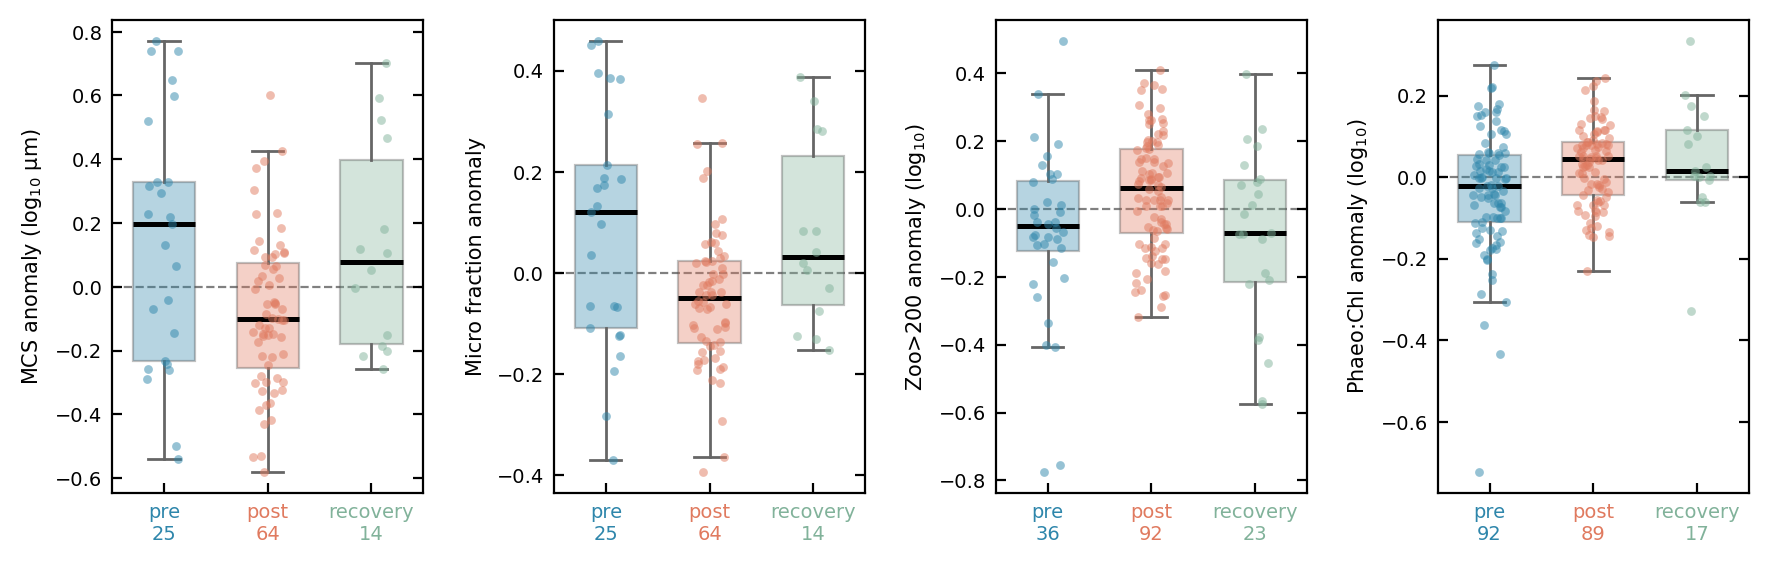

deseasonalised anomaly — median by era (pre / post / recovery):
  MCS     +0.196 / -0.101 / +0.079
  Micro   +0.120 / -0.050 / +0.030
  Zoo     -0.051 / +0.062 / -0.073
  Phaeo   -0.021 / +0.043 / +0.015


In [6]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 exploration — DESEASONALISED boxplots, FULL dataset (no regime split).
# Anomaly = value minus its calendar-month climatology (same deseasonalisation as panel (a)/Fig 1).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df.date.dt.year < 2005, 'pre',
            np.where(df.date.dt.year < 2014, 'post', 'recovery'))
df['mo'] = df.date.dt.month
df['micro_frac'] = df['micro_mmolN'] / df[['pico_mmolN','nano_mmolN','micro_mmolN']].sum(axis=1)

# (column, short, ylabel, transform)
METRICS = [('size_centroid',   'MCS',   'MCS anomaly (log$_{10}$ µm)',   lambda v: v),
           ('micro_frac',      'Micro', 'Micro fraction anomaly',         lambda v: v),
           ('zoo_gt200_mmolN', 'Zoo',   'Zoo>200 anomaly (log$_{10}$)',   lambda v: np.log10(v)),
           ('PhaeoChl_ratio',  'Phaeo', 'Phaeo:Chl anomaly (log$_{10}$)', lambda v: np.log10(v))]

rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 4, figsize=(8.8, 3.2))
fig.subplots_adjust(left=0.06, right=0.99, top=0.90, bottom=0.16, wspace=0.42)
summ = {}
for ax, (col, short, lab, tf) in zip(axes, METRICS):
    s = df.dropna(subset=[col]).copy()
    s['t'] = tf(s[col].astype(float))
    s['anom'] = s['t'] - s.groupby('mo')['t'].transform('mean')
    data = [s[s.era == e]['anom'].values for e in ERA_ORDER]
    bp = ax.boxplot(data, positions=range(3), widths=0.6, showfliers=False, patch_artist=True,
                    medianprops=dict(color='black', lw=1.8), whiskerprops=dict(color='0.4'),
                    capprops=dict(color='0.4'), boxprops=dict(lw=0.8, edgecolor='0.3'))
    for patch, e in zip(bp['boxes'], ERA_ORDER):
        patch.set_facecolor(ERA_COL[e]); patch.set_alpha(0.35)
    for i, e in enumerate(ERA_ORDER):
        ax.scatter(i + rng.uniform(-0.16, 0.16, len(data[i])), data[i], s=10,
                   color=ERA_COL[e], alpha=0.5, lw=0, zorder=3)
    ax.axhline(0, color='0.5', ls='--', lw=0.8, zorder=1)
    ax.set_xticks(range(3))
    ax.set_xticklabels([f'{e}\n{len(data[i])}' for i, e in enumerate(ERA_ORDER)], fontsize=7)
    for t, e in zip(ax.get_xticklabels(), ERA_ORDER): t.set_color(ERA_COL[e])
    ax.set_ylabel(lab, fontsize=7.5)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7)
    summ[short] = {e: np.median(data[i]) for i, e in enumerate(ERA_ORDER)}
plt.show()

print("deseasonalised anomaly — median by era (pre / post / recovery):")
for k, v in summ.items():
    print(f"  {k:7s} {v['pre']:+.3f} / {v['post']:+.3f} / {v['recovery']:+.3f}")

In [10]:
# Which months drive Phaeo:Chl? Top overall + top within post, with context.
import numpy as np, pandas as pd
from cariaco_obs import DEFAULT_CSV_PATH
df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery'))
df['month'] = df.date.dt.strftime('%Y-%m')
reg = 'regime_adjusted' if 'regime_adjusted' in df.columns else 'upwelling'
cols = [c for c in ['month','era',reg,'PhaeoChl_ratio','Phaeo_niskin_mgm3','Chl_niskin_mgm3',
                    'temp_50m','FN_mmolN_m2_d'] if c in df.columns]
d = df.dropna(subset=['PhaeoChl_ratio'])
print("TOP 8 Phaeo:Chl overall:\n", d.nlargest(12,'PhaeoChl_ratio')[cols].to_string(index=False))
print("\nTOP 5 within POST:\n", d[d.era=='post'].nlargest(5,'PhaeoChl_ratio')[cols].to_string(index=False))
print("\nby era — median / max:")
for e in ['pre','post','recovery']:
    s=d[d.era==e]['PhaeoChl_ratio']; print(f"  {e:9s} med={s.median():.2f}  max={s.max():.2f}")

TOP 8 Phaeo:Chl overall:
   month      era regime_adjusted  PhaeoChl_ratio  Phaeo_niskin_mgm3  Chl_niskin_mgm3  temp_50m  FN_mmolN_m2_d
2001-11      pre         relaxed        2.061534           0.371043         0.179984 24.408000       1.191752
2013-12     post         relaxed        1.774403           0.294718         0.166094 23.212411       1.222353
2014-11 recovery         relaxed        1.738173           0.445026         0.256031 24.661369       2.352499
2002-06      pre         relaxed        1.708131           0.341960         0.200195 22.793000       0.811266
2014-10 recovery         relaxed        1.671102           0.311482         0.186393 24.109349       1.526313
2003-12      pre         relaxed        1.669624           0.274295         0.164286 25.111150       0.654951
2002-10      pre         relaxed        1.668631           0.452585         0.271231 24.975000       1.757628
2001-12      pre         relaxed        1.662652           0.414497         0.249298 24.284000

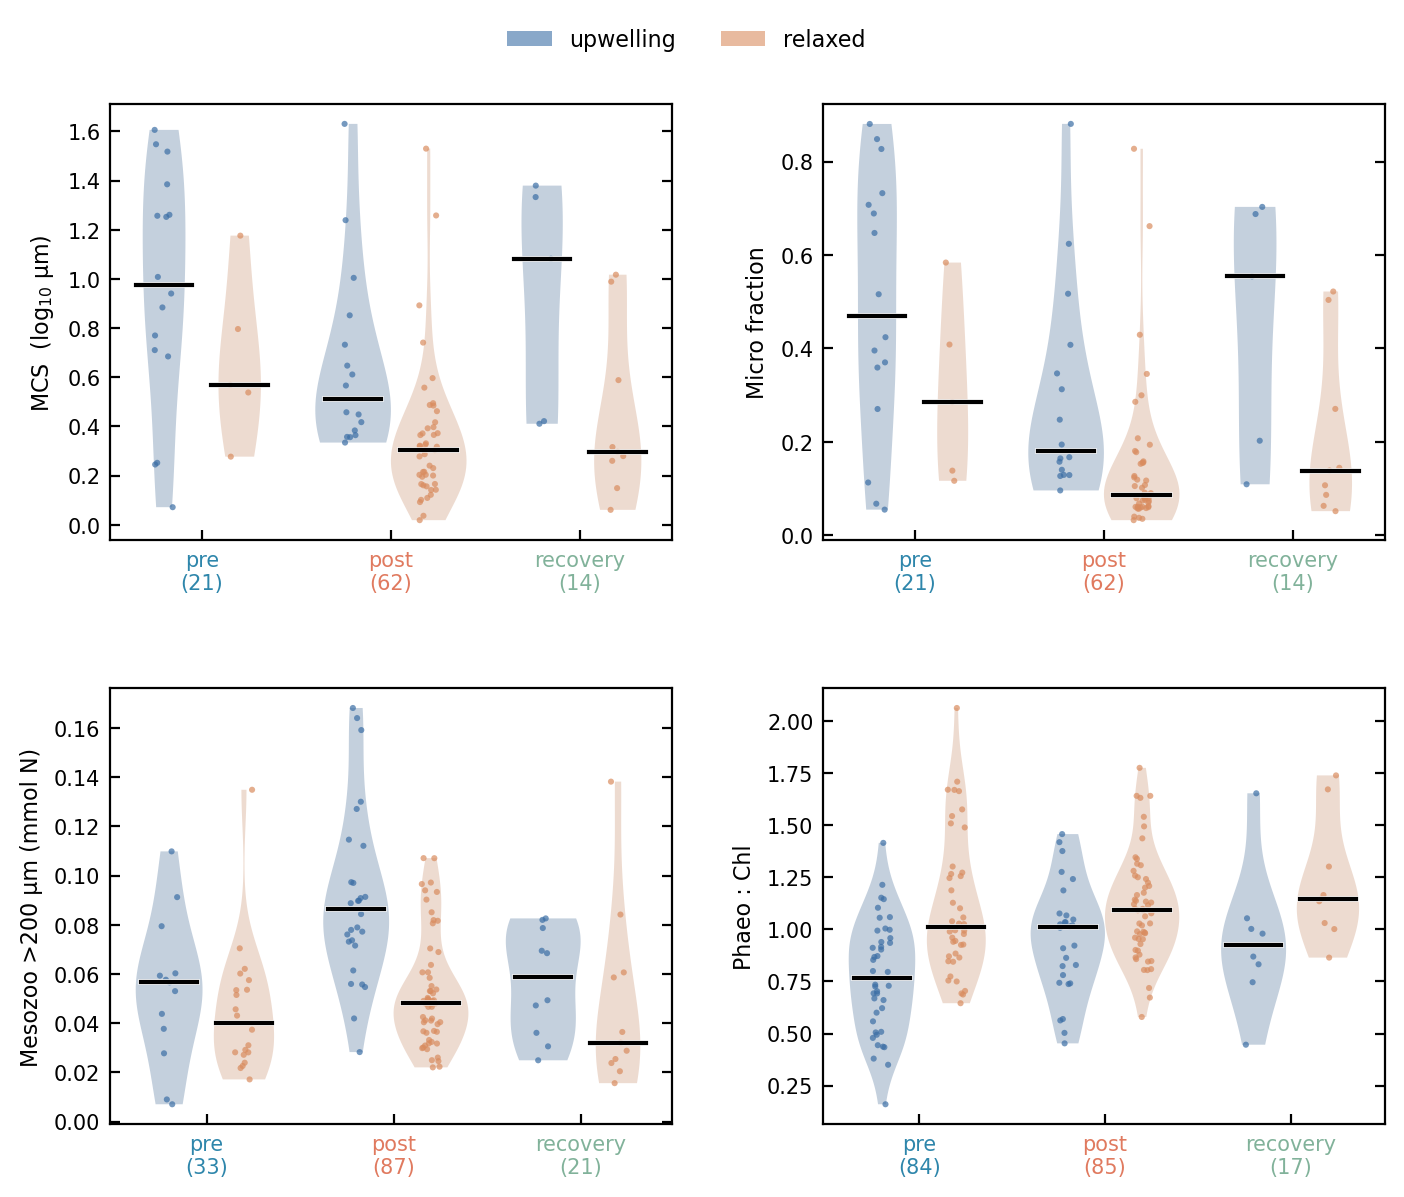

In [8]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 overview — four metrics; PAIRED upwelling/relaxed violins per era (not split).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns, matplotlib.patheffects as pe
from matplotlib.patches import Patch
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre','post','recovery']
ERA_COL = {'pre':'#2E86AB','post':'#E07A5F','recovery':'#81B29A'}
REG_ORDER = ['upwelling','relaxed']; REG_COL = {'upwelling':'#3B6EA5','relaxed':'#D98C5F'}
HALO = [pe.withStroke(linewidth=2.0, foreground='white')]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery'))
reg = 'regime_adjusted' if 'regime_adjusted' in df.columns else 'upwelling'
df['micro_frac'] = df['micro_mmolN']/df[['pico_mmolN','nano_mmolN','micro_mmolN']].sum(axis=1)
d = df[df[reg].isin(REG_ORDER)].copy()
METRICS = [('size_centroid','MCS  (log$_{10}$ µm)'),('micro_frac','Micro fraction'),
           ('zoo_gt200_mmolN','Mesozoo >200 µm (mmol N)'),('PhaeoChl_ratio','Phaeo : Chl')]

fig, axes = plt.subplots(2,2, figsize=(7.2,6.0))
fig.subplots_adjust(left=0.10, right=0.985, top=0.92, bottom=0.07, hspace=0.34, wspace=0.27)
for ax,(col,lab) in zip(axes.ravel(), METRICS):
    dd = d.dropna(subset=[col])
    sns.violinplot(data=dd, x='era', y=col, order=ERA_ORDER, hue=reg, hue_order=REG_ORDER,
                   split=False, dodge=True, palette=REG_COL, inner=None, cut=0,
                   linewidth=0.6, legend=False, ax=ax)
    for v in ax.collections: v.set_alpha(0.32); v.set_edgecolor('none')
    sns.stripplot(data=dd, x='era', y=col, order=ERA_ORDER, hue=reg, hue_order=REG_ORDER,
                  dodge=True, palette=REG_COL, size=2.2, alpha=0.7, jitter=0.10, legend=False, ax=ax)
    for i,e in enumerate(ERA_ORDER):
        for k,r in enumerate(REG_ORDER):
            s = dd[(dd.era==e)&(dd[reg]==r)][col]
            if len(s):
                x0 = i + (-0.2 if k==0 else 0.2)
                ax.plot([x0-0.15,x0+0.15],[s.median()]*2,color='black',lw=1.5,zorder=6,path_effects=HALO)
    ax.set_xlabel(''); ax.set_ylabel(lab, fontsize=8)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
    ax.set_xticks(range(3))
    ax.set_xticklabels([f'{e}\n({len(dd[dd.era==e])})' for e in ERA_ORDER], fontsize=7.5)
    for t,e in zip(ax.get_xticklabels(), ERA_ORDER): t.set_color(ERA_COL[e])
fig.legend(handles=[Patch(facecolor=REG_COL[r], alpha=0.6, label=r) for r in REG_ORDER],
           loc='upper center', ncol=2, frameon=False, fontsize=8, bbox_to_anchor=(0.5,1.0))
plt.show()

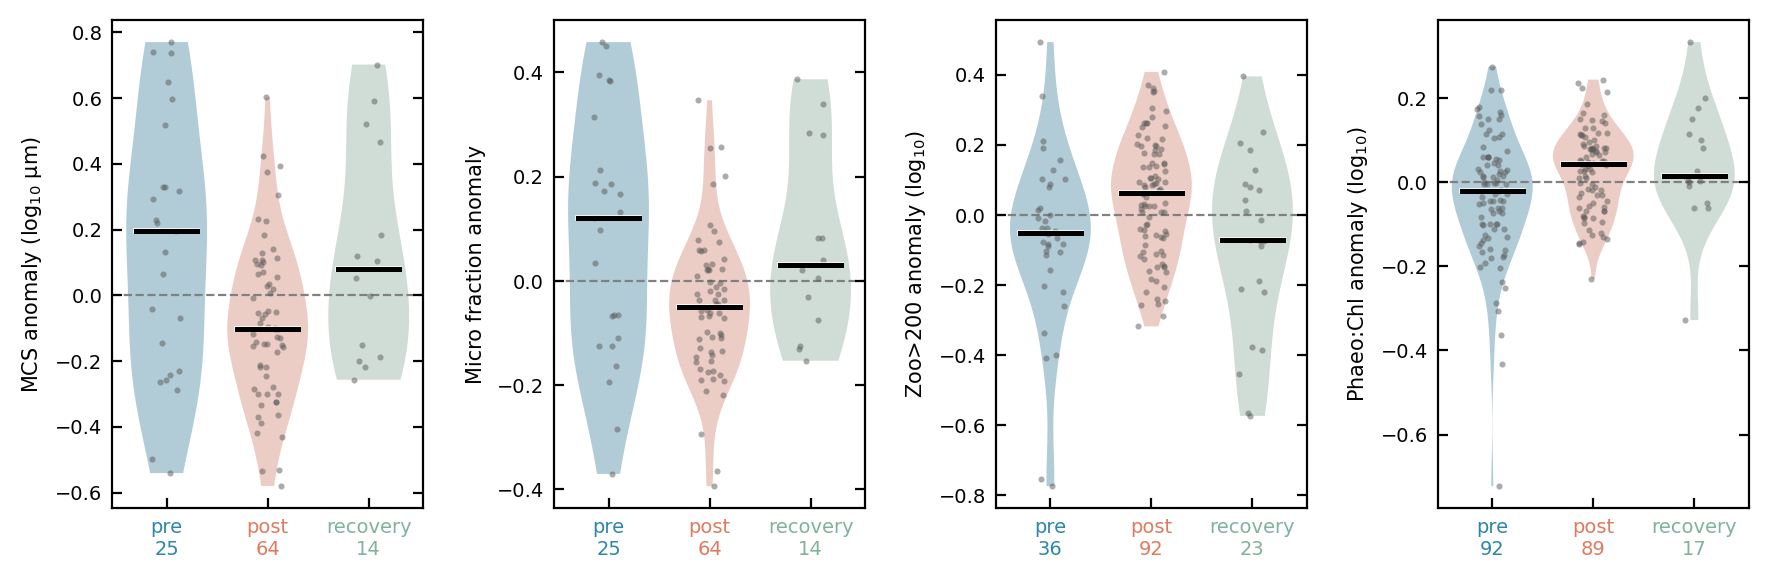

deseasonalised anomaly — median by era (pre/post/recovery):
  MCS     +0.196 / -0.101 / +0.079
  Micro   +0.120 / -0.050 / +0.030
  Zoo     -0.051 / +0.062 / -0.073
  Phaeo   -0.021 / +0.043 / +0.015


In [9]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 — DESEASONALISED anomalies as violins, full dataset (no regime split). 4 metrics.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns, matplotlib.patheffects as pe
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre','post','recovery']
ERA_COL = {'pre':'#2E86AB','post':'#E07A5F','recovery':'#81B29A'}
HALO = [pe.withStroke(linewidth=2.0, foreground='white')]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery'))
df['mo'] = df.date.dt.month
df['micro_frac'] = df['micro_mmolN']/df[['pico_mmolN','nano_mmolN','micro_mmolN']].sum(axis=1)
METRICS = [('size_centroid','MCS','MCS anomaly (log$_{10}$ µm)',lambda v:v),
           ('micro_frac','Micro','Micro fraction anomaly',lambda v:v),
           ('zoo_gt200_mmolN','Zoo','Zoo>200 anomaly (log$_{10}$)',lambda v:np.log10(v)),
           ('PhaeoChl_ratio','Phaeo','Phaeo:Chl anomaly (log$_{10}$)',lambda v:np.log10(v))]

fig, axes = plt.subplots(1,4, figsize=(8.8,3.3))
fig.subplots_adjust(left=0.06, right=0.99, top=0.90, bottom=0.16, wspace=0.42)
summ = {}
for ax,(col,short,lab,tf) in zip(axes, METRICS):
    s = df.dropna(subset=[col]).copy()
    s['t'] = tf(s[col].astype(float)); s['anom'] = s['t'] - s.groupby('mo')['t'].transform('mean')
    sns.violinplot(data=s, x='era', y='anom', order=ERA_ORDER, hue='era', palette=ERA_COL,
                   legend=False, inner=None, cut=0, linewidth=0.7, ax=ax)
    for v in ax.collections: v.set_alpha(0.40); v.set_edgecolor('none')
    sns.stripplot(data=s, x='era', y='anom', order=ERA_ORDER, color='0.35', size=2.2,
                  alpha=0.5, jitter=0.15, ax=ax)
    for i,e in enumerate(ERA_ORDER):
        m = s[s.era==e]['anom'].median()
        ax.plot([i-0.3,i+0.3],[m,m],color='black',lw=1.8,zorder=6,path_effects=HALO)
        summ.setdefault(short,{})[e] = m
    ax.axhline(0, color='0.5', ls='--', lw=0.8, zorder=1)
    ax.set_xlabel(''); ax.set_ylabel(lab, fontsize=7.5)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7)
    ax.set_xticks(range(3))
    ax.set_xticklabels([f'{e}\n{len(s[s.era==e])}' for e in ERA_ORDER], fontsize=7)
    for t,e in zip(ax.get_xticklabels(), ERA_ORDER): t.set_color(ERA_COL[e])
plt.show()
print("deseasonalised anomaly — median by era (pre/post/recovery):")
for k,v in summ.items(): print(f"  {k:7s} {v['pre']:+.3f} / {v['post']:+.3f} / {v['recovery']:+.3f}")

FOLD SCREEN  — score = mean(|δ pre-post|,|δ rec-post|) if same sign else 0,  minus |δ pre-rec|
higher = pre & rec close AND both apart from post.  KSpr = pre↔rec KS (low = same distribution).  n = pre/post/rec

                                     n dir   raw  deseas   upw   rel  KSpr
col                                                                       
depth_cutoff                  92/89/17   -  0.24    0.34  0.27 -0.05  0.13
nbss_slope                    25/64/14   +  0.10    0.33  0.38  0.03  0.17
slope_2pt                     25/64/14   +  0.10    0.33  0.38  0.03  0.17
size_centroid                 25/64/14   +  0.06    0.30  0.36 -0.01  0.23
micro_frac_N                  25/64/14   +  0.08    0.29  0.27  0.06  0.27
micro_frac                    25/64/14   +  0.08    0.29  0.25  0.06  0.27
pico_frac_N                   25/64/14   -  0.01    0.29  0.33 -0.16  0.20
pico_frac                     25/64/14   -  0.01    0.28  0.33 -0.16  0.20
Chl_niskin_mgm3               92/89/17 

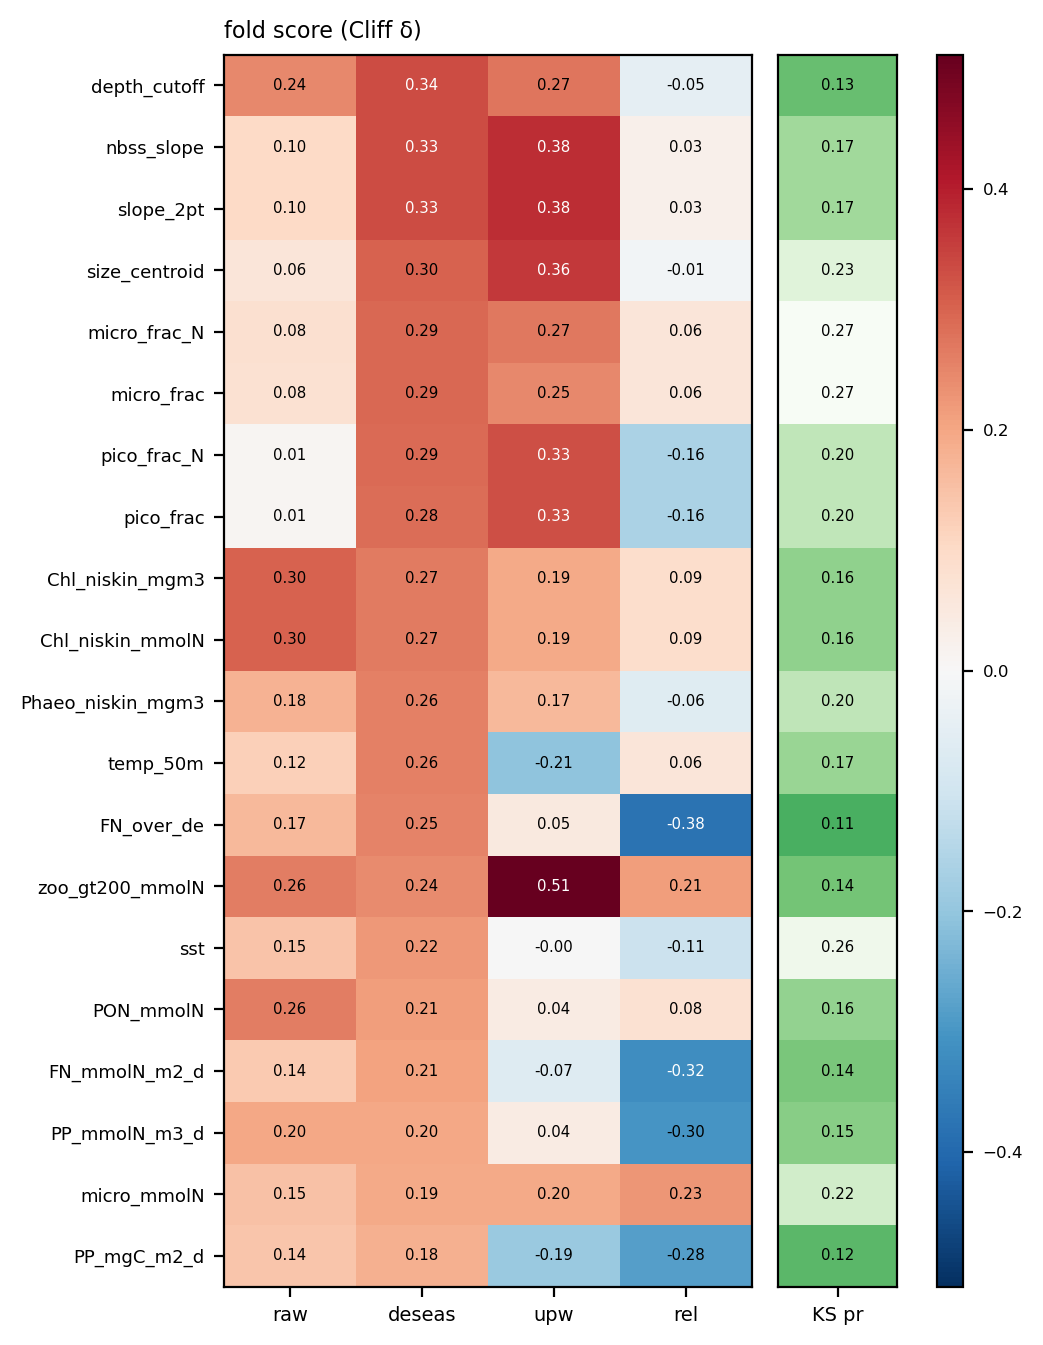

In [14]:
%config InlineBackend.figure_format='retina'
# Fig 3 — FOLD SCREEN. Which obs columns put pre & recovery close, both apart from post?
# Eras individual. Views: raw | deseasonalised | upwelling | relaxed.
# Cliff's delta (location) -> fold score ; KS on pre-recovery (distribution/shape match).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery'))
df['mo']  = df.date.dt.month
reg = 'regime_adjusted' if 'regime_adjusted' in df.columns else 'upwelling'

# derived supply / composition candidates
if {'FN_mmolN_m2_d','depth_cutoff'} <= set(df.columns):
    df['FN_over_de'] = df['FN_mmolN_m2_d'] / df['depth_cutoff'].replace(0, np.nan)
binc = [c for c in ['pico_mmolN','nano_mmolN','micro_mmolN'] if c in df.columns]
if len(binc)==3:
    tot = df[binc].sum(axis=1, min_count=3); df['sumP_mmolN'] = tot
    for b in binc: df[b.replace('_mmolN','_frac')] = df[b]/tot

BLACK = ('date','year','month','time','flag','boundary','era','regime','upwelling','ui','lat','lon')
cands = [c for c in df.select_dtypes(include='number').columns
         if c != 'mo' and not any(b in c.lower() for b in BLACK)]
ERAS = ['pre','post','recovery']

def cliff(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float); a=a[~np.isnan(a)]; b=b[~np.isnan(b)]
    return np.nan if (len(a)<2 or len(b)<2) else np.sign(a[:,None]-b[None,:]).mean()
def ks(a,b):
    a=pd.Series(a).dropna(); b=pd.Series(b).dropna()
    return np.nan if (len(a)<3 or len(b)<3) else ks_2samp(a,b).statistic
def fold(vals):
    dpp,drp,dpr = cliff(vals['pre'],vals['post']), cliff(vals['recovery'],vals['post']), cliff(vals['pre'],vals['recovery'])
    if np.isnan(dpp) or np.isnan(drp): sep=np.nan
    elif np.sign(dpp)==np.sign(drp) and dpp!=0 and drp!=0: sep=np.mean([abs(dpp),abs(drp)])
    else: sep=0.0
    return dpp,drp,dpr, sep-(abs(dpr) if not np.isnan(dpr) else 0.0)

def vals_for(col, view):
    if view=='deseas':
        x = df[col]-df.groupby('mo')[col].transform('mean'); base=df
    elif view=='upw': x=df[col]; base=df[df[reg]=='upwelling']; x=base[col]
    elif view=='rel': x=df[col]; base=df[df[reg]=='relaxed']; x=base[col]
    else: base=df; x=df[col]
    return {e: x[base.era==e].values for e in ERAS}

VIEWS=['raw','deseas','upw','rel']; rows=[]
for col in cands:
    rec={'col':col, 'n':'/'.join(str(df[df.era==e][col].notna().sum()) for e in ERAS)}
    for v in VIEWS:
        vv=vals_for(col,v); dpp,drp,dpr,sc = fold(vv); rec[v]=sc
        if v=='deseas':
            rec['dir']='+' if (np.isfinite(dpp) and dpp>0) else ('-' if np.isfinite(dpp) else '?')
            rec['KSpr']=ks(vv['pre'],vv['recovery'])
    rows.append(rec)
R = pd.DataFrame(rows).set_index('col').sort_values('deseas', ascending=False)

print("FOLD SCREEN  — score = mean(|δ pre-post|,|δ rec-post|) if same sign else 0,  minus |δ pre-rec|")
print("higher = pre & rec close AND both apart from post.  KSpr = pre↔rec KS (low = same distribution).  n = pre/post/rec\n")
print(R[['n','dir','raw','deseas','upw','rel','KSpr']].to_string(float_format=lambda x:f'{x:.2f}'))

print("\nTop 8 (deseasonalised) — δ pre-post / rec-post / pre-rec | KSpr | deseas median pre/post/rec:")
for col in R.head(8).index:
    vv=vals_for(col,'deseas'); dpp,drp,dpr,_=fold(vv)
    m=[np.nanmedian(vv[e]) for e in ERAS]
    print(f"  {col:22s} {dpp:+.2f}/{drp:+.2f}/{dpr:+.2f} | KS {ks(vv['pre'],vv['recovery']):.2f} | {m[0]:+.3f}/{m[1]:+.3f}/{m[2]:+.3f}")

# ---- minimalistic visual: score heatmap across views + KSpr column ----
top=R.head(min(20,len(R))); M=top[['raw','deseas','upw','rel']].values.astype(float)
K=top[['KSpr']].values.astype(float); nrow=len(top)
fig=plt.figure(figsize=(6.6,0.30*nrow+1.0))
axS=fig.add_axes([0.32,0.06,0.40,0.88]); axK=fig.add_axes([0.74,0.06,0.09,0.88]); cax=fig.add_axes([0.86,0.06,0.02,0.88])
vmax=np.nanmax(np.abs(M[np.isfinite(M)])) if np.isfinite(M).any() else 1.0
im=axS.imshow(M,cmap='RdBu_r',vmin=-vmax,vmax=vmax,aspect='auto')
axS.set_xticks(range(4)); axS.set_xticklabels(VIEWS,fontsize=7)
axS.set_yticks(range(nrow)); axS.set_yticklabels(top.index,fontsize=6.5)
for i in range(nrow):
    for j in range(4):
        if np.isfinite(M[i,j]): axS.text(j,i,f'{M[i,j]:.2f}',ha='center',va='center',fontsize=5.4,
                                         color='w' if abs(M[i,j])>0.6*vmax else 'k')
axS.set_title('fold score (Cliff δ)',fontsize=8,loc='left')
kmax=np.nanmax(K[np.isfinite(K)]) if np.isfinite(K).any() else 1.0
axK.imshow(K,cmap='Greens_r',vmin=0,vmax=kmax,aspect='auto'); axK.set_yticks([])
axK.set_xticks([0]); axK.set_xticklabels(['KS pr'],fontsize=7)
for i in range(nrow):
    if np.isfinite(K[i,0]): axK.text(0,i,f'{K[i,0]:.2f}',ha='center',va='center',fontsize=5.4,color='k')
fig.colorbar(im,cax=cax).ax.tick_params(labelsize=6)
plt.show()

In [17]:
# Fig 3 — diagnostics, SPLIT: (1) pooled era comparison [main]  (2) regime split [supplementary].
import numpy as np, pandas as pd
from scipy.stats import ks_2samp, mannwhitneyu
from cariaco_obs import DEFAULT_CSV_PATH

df=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
df['era']=np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery'))
df['mo']=df.date.dt.month
reg='regime_adjusted' if 'regime_adjusted' in df.columns else 'upwelling'
VARS=[('N (F_N)','FN_mmolN_m2_d'),('P (MCS)','size_centroid'),('Z (zoo>200)','zoo_gt200_mmolN')]
PAIRS=[('pre','post'),('recovery','post'),('pre','recovery')]

def cliff(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float); a=a[~np.isnan(a)]; b=b[~np.isnan(b)]
    return np.nan if(len(a)<2 or len(b)<2) else np.sign(a[:,None]-b[None,:]).mean()
def ks(a,b):
    a=pd.Series(a).dropna(); b=pd.Series(b).dropna()
    return np.nan if(len(a)<3 or len(b)<3) else ks_2samp(a,b).statistic
def mw(a,b):
    a=pd.Series(a).dropna(); b=pd.Series(b).dropna()
    return np.nan if(len(a)<3 or len(b)<3) else mannwhitneyu(a,b,alternative='two-sided')[1]

A={}
for vlab,col in VARS:
    s=df.dropna(subset=[col]).copy(); s['anom']=s[col]-s.groupby('mo')[col].transform('mean'); A[vlab]=s

def row(vlab,sub,a,b):
    x=sub[sub.era==a]['anom']; y=sub[sub.era==b]['anom']
    return (f"{vlab:11s} {a+'-'+b:16s} {f'{x.notna().sum()},{y.notna().sum()}':>8s} "
            f"{x.median():>7.3f} {y.median():>7.3f} {cliff(x,y):>+6.2f} {ks(x,y):>5.2f} {mw(x,y):>7.2g}")
hdr=f"{'var':11s} {'pair':16s} {'n1,n2':>8s} {'med1':>7s} {'med2':>7s} {'δ':>6s} {'KS':>5s} {'p':>7s}"

print("TABLE 1 — POOLED era comparison (deseasonalised).  δ=Cliff location | KS=distribution | p=MW (optimistic)")
print(hdr)
for vlab,_ in VARS:
    for a,b in PAIRS: print(row(vlab,A[vlab],a,b))
    print()

print("\nTABLE 2 — REGIME SPLIT (deseasonalised; supplementary; small n by construction).")
print(f"{'regime':10s} "+hdr)
for regime in ['upwelling','relaxed']:
    for vlab,_ in VARS:
        sub=A[vlab][A[vlab][reg]==regime]
        for a,b in PAIRS: print(f"{regime:10s} "+row(vlab,sub,a,b))
        print()

TABLE 1 — POOLED era comparison (deseasonalised).  δ=Cliff location | KS=distribution | p=MW (optimistic)
var         pair                n1,n2    med1    med2      δ    KS       p
N (F_N)     pre-post            88,80  -0.095  -0.494  +0.22  0.23   0.012
N (F_N)     recovery-post       17,80   0.082  -0.494  +0.25  0.31     0.1
N (F_N)     pre-recovery        88,17  -0.095   0.082  -0.03  0.14    0.83

P (MCS)     pre-post            25,64   0.196  -0.101  +0.35  0.42   0.011
P (MCS)     recovery-post       14,64   0.079  -0.101  +0.33  0.30   0.052
P (MCS)     pre-recovery        25,14   0.196   0.079  +0.04  0.23    0.85

Z (zoo>200) pre-post            36,92  -0.009   0.002  -0.28  0.32   0.014
Z (zoo>200) recovery-post       23,92  -0.007   0.002  -0.26  0.25   0.054
Z (zoo>200) pre-recovery        36,23  -0.009  -0.007  -0.03  0.14    0.86


TABLE 2 — REGIME SPLIT (deseasonalised; supplementary; small n by construction).
regime     var         pair                n1,n2    med1   

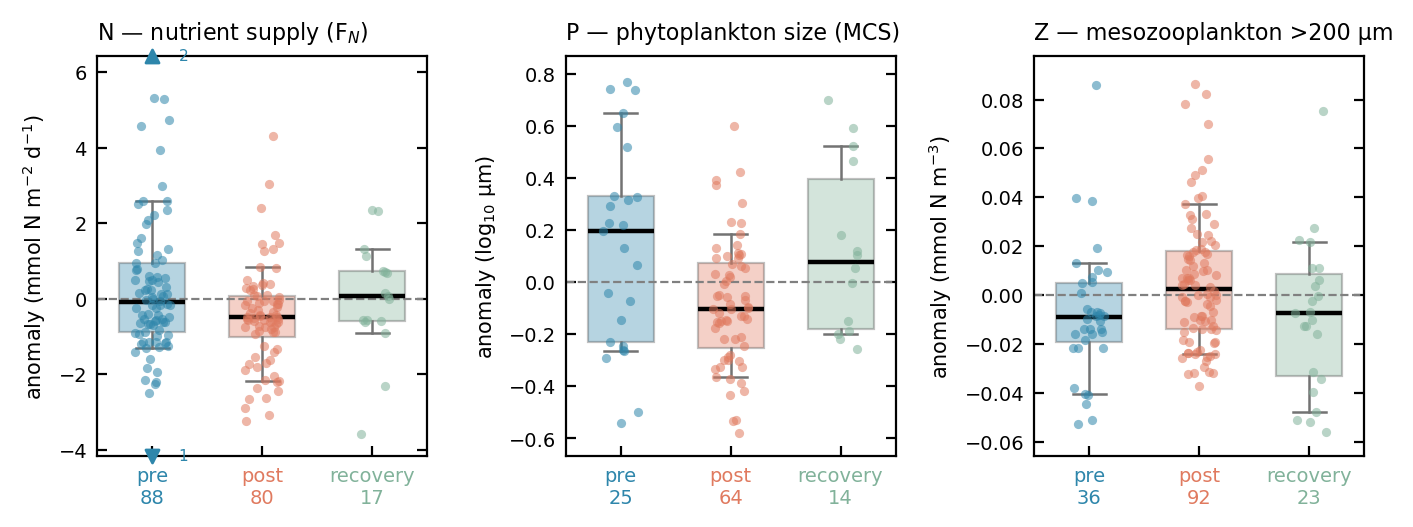

In [18]:
%config InlineBackend.figure_format='retina'
# Fig 3 middle — OPTION 1: clipped box + dots; off-scale months flagged at edges.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH
ERA=['pre','post','recovery']; EC={'pre':'#2E86AB','post':'#E07A5F','recovery':'#81B29A'}
df=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
df['era']=np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery')); df['mo']=df.date.dt.month
PAN=[('N — nutrient supply (F$_N$)','FN_mmolN_m2_d','mmol N m$^{-2}$ d$^{-1}$'),
     ('P — phytoplankton size (MCS)','size_centroid','log$_{10}$ µm'),
     ('Z — mesozooplankton >200 µm','zoo_gt200_mmolN','mmol N m$^{-3}$')]
rng=np.random.default_rng(0)
fig,axes=plt.subplots(1,3,figsize=(7.0,2.9)); fig.subplots_adjust(left=0.085,right=0.99,top=0.86,bottom=0.17,wspace=0.42)
for ax,(title,col,unit) in zip(axes,PAN):
    s=df.dropna(subset=[col]).copy(); s['a']=s[col]-s.groupby('mo')[col].transform('mean')
    data=[s[s.era==e]['a'].values for e in ERA]; allv=np.concatenate(data)
    lo,hi=np.nanpercentile(allv,[1,99]); pad=0.10*(hi-lo); lo-=pad; hi+=pad
    bp=ax.boxplot(data,positions=range(3),widths=0.6,showfliers=False,patch_artist=True,whis=[10,90],
                  medianprops=dict(color='k',lw=1.6),whiskerprops=dict(color='0.45',lw=0.9),
                  capprops=dict(color='0.45',lw=0.9),boxprops=dict(lw=0.8,edgecolor='0.3'))
    for p,e in zip(bp['boxes'],ERA): p.set_facecolor(EC[e]); p.set_alpha(0.35)
    for i,e in enumerate(ERA):
        v=data[i]; inr=v[(v>=lo)&(v<=hi)]; ab=(v>hi).sum(); be=(v<lo).sum()
        ax.scatter(i+rng.uniform(-0.16,0.16,len(inr)),inr,s=11,color=EC[e],alpha=0.55,lw=0,zorder=3)
        if ab: ax.scatter(i,hi,marker='^',s=22,color=EC[e],clip_on=False,zorder=5); ax.text(i+0.24,hi,f'{ab}',fontsize=5.5,color=EC[e],va='center')
        if be: ax.scatter(i,lo,marker='v',s=22,color=EC[e],clip_on=False,zorder=5); ax.text(i+0.24,lo,f'{be}',fontsize=5.5,color=EC[e],va='center')
    ax.axhline(0,color='0.5',ls='--',lw=0.8); ax.set_ylim(lo,hi)
    ax.set_xticks(range(3)); ax.set_xticklabels([f'{e}\n{len(data[i])}' for i,e in enumerate(ERA)],fontsize=7)
    for t,e in zip(ax.get_xticklabels(),ERA): t.set_color(EC[e])
    ax.set_title(title,loc='left',fontsize=8); ax.set_ylabel('anomaly ('+unit+')',fontsize=7.5)
    ax.tick_params(top=False,right=True,direction='in',labelsize=7)
plt.show()

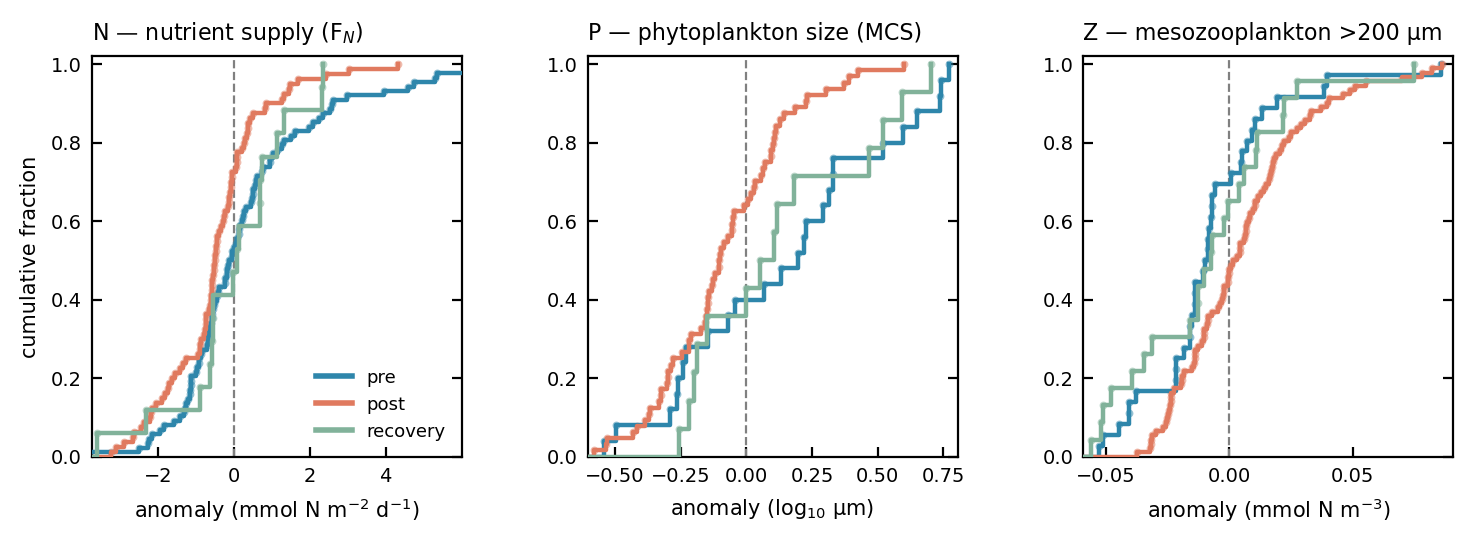

In [19]:
%config InlineBackend.figure_format='retina'
# Fig 3 middle — OPTION 2: ECDF per era (cumulative fraction). x clipped to robust range.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cariaco_obs import DEFAULT_CSV_PATH
ERA=['pre','post','recovery']; EC={'pre':'#2E86AB','post':'#E07A5F','recovery':'#81B29A'}
df=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
df['era']=np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery')); df['mo']=df.date.dt.month
PAN=[('N — nutrient supply (F$_N$)','FN_mmolN_m2_d','anomaly (mmol N m$^{-2}$ d$^{-1}$)'),
     ('P — phytoplankton size (MCS)','size_centroid','anomaly (log$_{10}$ µm)'),
     ('Z — mesozooplankton >200 µm','zoo_gt200_mmolN','anomaly (mmol N m$^{-3}$)')]
fig,axes=plt.subplots(1,3,figsize=(7.4,2.9)); fig.subplots_adjust(left=0.07,right=0.99,top=0.86,bottom=0.17,wspace=0.34)
for ax,(title,col,unit) in zip(axes,PAN):
    s=df.dropna(subset=[col]).copy(); s['a']=s[col]-s.groupby('mo')[col].transform('mean')
    lo,hi=np.nanpercentile(s['a'],[1,99]); pad=0.05*(hi-lo); lo-=pad; hi+=pad
    for e in ERA:
        v=np.sort(s[s.era==e]['a'].dropna().values); y=np.arange(1,len(v)+1)/len(v)
        ax.step(np.r_[lo,v],np.r_[0,y],where='post',color=EC[e],lw=1.6,zorder=4)
        ax.scatter(v,y,s=8,color=EC[e],alpha=0.5,lw=0,zorder=3)
    ax.axvline(0,color='0.5',ls='--',lw=0.8); ax.set_xlim(lo,hi); ax.set_ylim(0,1.02)
    ax.set_title(title,loc='left',fontsize=8); ax.set_xlabel(unit,fontsize=7.5)
    ax.tick_params(top=False,right=True,direction='in',labelsize=7)
axes[0].set_ylabel('cumulative fraction',fontsize=7.5)
axes[0].legend(handles=[Line2D([0],[0],color=EC[e],lw=2,label=e) for e in ERA],loc='lower right',frameon=False,fontsize=6.5)
plt.show()

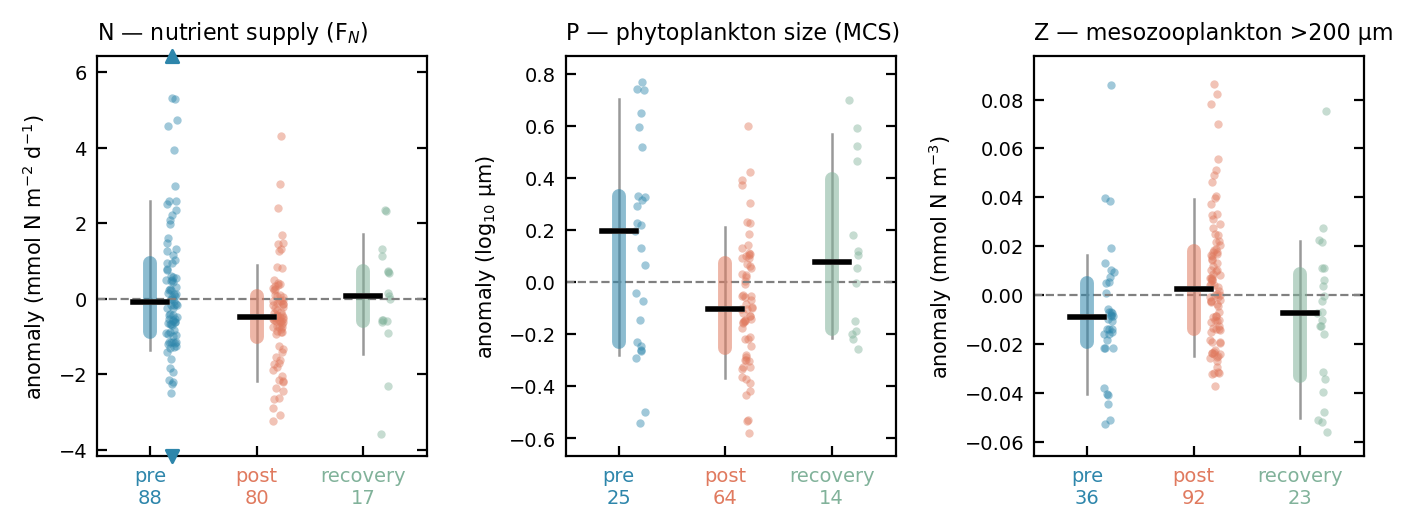

In [20]:
%config InlineBackend.figure_format='retina'
# Fig 3 middle — OPTION 3: median + IQR bar + 10-90 + dots (no box), clipped & flagged.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from cariaco_obs import DEFAULT_CSV_PATH
ERA=['pre','post','recovery']; EC={'pre':'#2E86AB','post':'#E07A5F','recovery':'#81B29A'}; HALO=[pe.withStroke(linewidth=2.0,foreground='white')]
df=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
df['era']=np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery')); df['mo']=df.date.dt.month
PAN=[('N — nutrient supply (F$_N$)','FN_mmolN_m2_d','mmol N m$^{-2}$ d$^{-1}$'),
     ('P — phytoplankton size (MCS)','size_centroid','log$_{10}$ µm'),
     ('Z — mesozooplankton >200 µm','zoo_gt200_mmolN','mmol N m$^{-3}$')]
rng=np.random.default_rng(0)
fig,axes=plt.subplots(1,3,figsize=(7.0,2.9)); fig.subplots_adjust(left=0.085,right=0.99,top=0.86,bottom=0.17,wspace=0.42)
for ax,(title,col,unit) in zip(axes,PAN):
    s=df.dropna(subset=[col]).copy(); s['a']=s[col]-s.groupby('mo')[col].transform('mean')
    data=[s[s.era==e]['a'].values for e in ERA]; allv=np.concatenate(data)
    lo,hi=np.nanpercentile(allv,[1,99]); pad=0.10*(hi-lo); lo-=pad; hi+=pad
    for i,e in enumerate(ERA):
        v=data[i]; q1,med,q3=np.percentile(v,[25,50,75]); p10,p90=np.percentile(v,[10,90])
        inr=v[(v>=lo)&(v<=hi)]; ab=(v>hi).sum(); be=(v<lo).sum()
        ax.scatter(i+0.20+rng.uniform(-0.05,0.05,len(inr)),inr,s=9,color=EC[e],alpha=0.45,lw=0,zorder=2)
        ax.plot([i,i],[p10,p90],color='0.6',lw=0.9,zorder=3)
        ax.plot([i,i],[q1,q3],color=EC[e],lw=5,alpha=0.55,solid_capstyle='round',zorder=4)
        ax.plot([i-0.16,i+0.16],[med,med],color='k',lw=2.0,zorder=6,path_effects=HALO)
        if ab: ax.scatter(i+0.20,hi,marker='^',s=20,color=EC[e],clip_on=False,zorder=5)
        if be: ax.scatter(i+0.20,lo,marker='v',s=20,color=EC[e],clip_on=False,zorder=5)
    ax.axhline(0,color='0.5',ls='--',lw=0.8); ax.set_ylim(lo,hi); ax.set_xlim(-0.5,2.6)
    ax.set_xticks(range(3)); ax.set_xticklabels([f'{e}\n{len(data[i])}' for i,e in enumerate(ERA)],fontsize=7)
    for t,e in zip(ax.get_xticklabels(),ERA): t.set_color(EC[e])
    ax.set_title(title,loc='left',fontsize=8); ax.set_ylabel('anomaly ('+unit+')',fontsize=7.5)
    ax.tick_params(top=False,right=True,direction='in',labelsize=7)
plt.show()

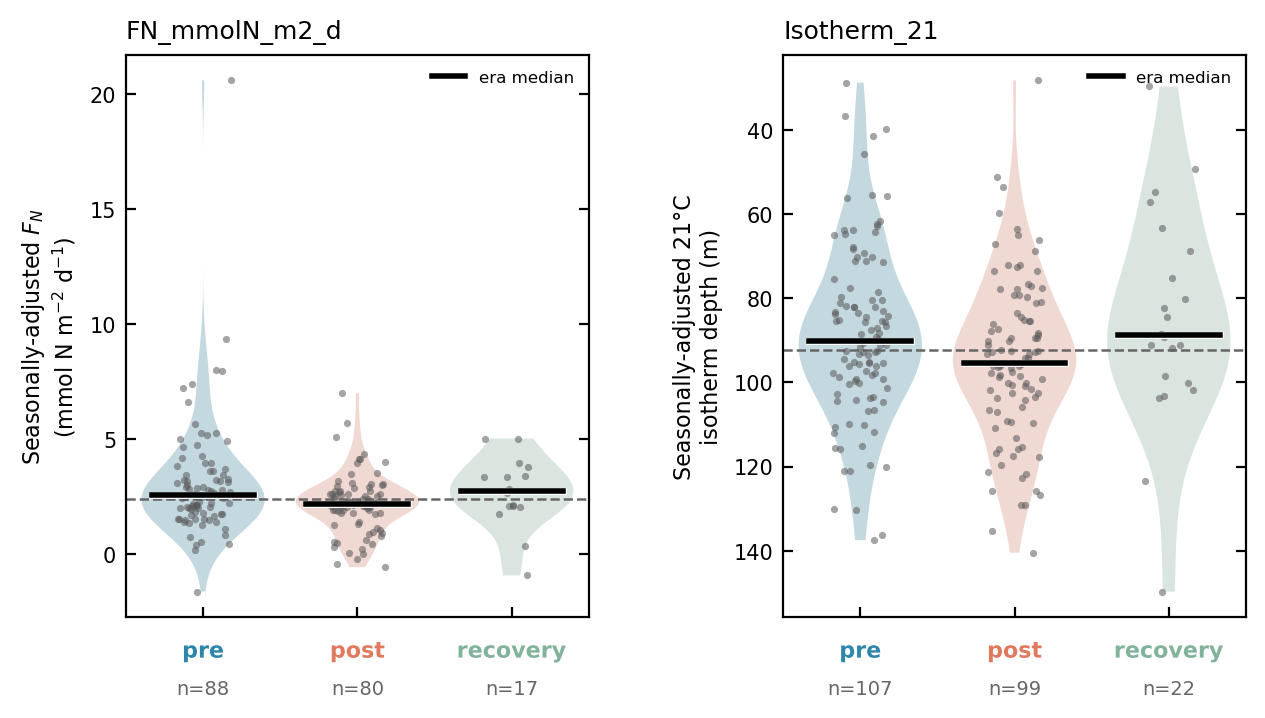

In [21]:
%config InlineBackend.figure_format='retina'
# Fig 3 N-window candidates — F_N vs Isotherm_21 as Panel-A-style violins (seasonally-adjusted, deseasonalised).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns, matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from cariaco_obs import DEFAULT_CSV_PATH

ERA=['pre','post','recovery']; EC={'pre':'#2E86AB','post':'#E07A5F','recovery':'#81B29A'}
HALO=[pe.withStroke(linewidth=2.5,foreground='white')]; LBL=[pe.withStroke(linewidth=2,foreground='white')]
df=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
df['era']=np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery'))
df['mo']=df.date.dt.month

CANDS=[('FN_mmolN_m2_d','Seasonally-adjusted $F_N$\n(mmol N m$^{-2}$ d$^{-1}$)',False),
       ('Isotherm_21','Seasonally-adjusted 21°C\nisotherm depth (m)',True)]   # invert -> shallower(up)=more upwelling

fig,axes=plt.subplots(1,2,figsize=(6.4,3.7))
fig.subplots_adjust(left=0.11,right=0.985,top=0.92,bottom=0.16,wspace=0.42)
for ax,(col,lab,invert) in zip(axes,CANDS):
    d=df.dropna(subset=[col]).copy()
    d['adj']=(d[col]-d.groupby('mo')[col].transform('mean'))+d[col].mean()   # seasonally-adjusted native units
    sns.violinplot(data=d,x='era',y='adj',order=ERA,hue='era',palette=EC,legend=False,
                   inner=None,cut=0,linewidth=0.8,ax=ax)
    for v in ax.collections: v.set_alpha(0.30); v.set_edgecolor('none')
    sns.stripplot(data=d,x='era',y='adj',order=ERA,color='0.35',size=2.6,alpha=0.55,jitter=0.18,ax=ax)
    for i,e in enumerate(ERA):
        m=d[d.era==e]['adj'].median(); ax.plot([i-0.33,i+0.33],[m,m],color='k',lw=2.0,zorder=6,path_effects=HALO)
    ax.axhline(d['adj'].median(),color='0.4',ls='--',lw=0.9,zorder=1)
    ax.set_xlim(-0.5,2.5)
    if invert: ax.invert_yaxis()
    ax.set_ylabel(lab,fontsize=8); ax.set_xlabel(''); ax.set_title(col,loc='left',fontsize=9)
    ax.tick_params(top=False,right=True,direction='in',labelsize=7.5)
    ax.set_xticks(range(3)); ax.set_xticklabels([])
    for i,e in enumerate(ERA):
        ax.text(i,-0.04,e,transform=ax.get_xaxis_transform(),ha='center',va='top',fontsize=8,
                color=EC[e],fontweight='bold',clip_on=False,path_effects=LBL)
        ax.text(i,-0.11,f'n={len(d[d.era==e])}',transform=ax.get_xaxis_transform(),ha='center',va='top',
                fontsize=7,color='0.4',clip_on=False)
    ax.legend(handles=[Line2D([0],[0],color='k',lw=2,label='era median')],loc='upper right',frameon=False,fontsize=6)
plt.show()

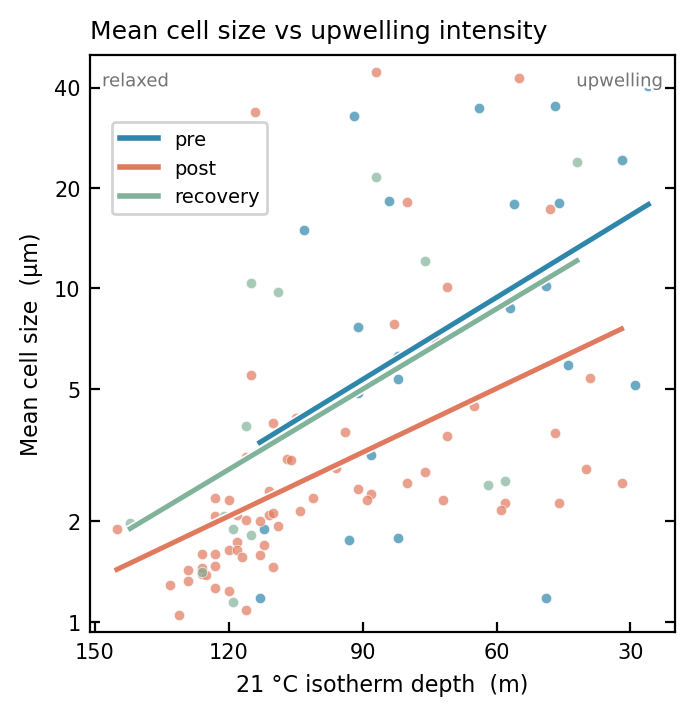

era          n   slope(logµm per m)     rho         p
all        103             -0.00812  -0.674     6e-15
pre         25             -0.00821  -0.487     0.014
post        64             -0.00639  -0.729   8.2e-12
recovery    14             -0.00803  -0.692    0.0061


In [22]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 Panel (c) — MCS vs Isotherm_21 (upwelling proxy), by era. x inverted: shallow/upwelling on right.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre','post','recovery']
ERA_COL = {'pre':'#2E86AB','post':'#E07A5F','recovery':'#81B29A'}
UM_TICKS = [1,2,5,10,20,40]
HALO3 = [pe.withStroke(linewidth=3.0, foreground='white')]
LBL_HALO = [pe.withStroke(linewidth=2, foreground='white')]
XCOL = 'Isotherm_21'

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year<2005,'pre',np.where(df['date'].dt.year<2014,'post','recovery'))
df['mcs_log'] = df['size_centroid']
d = df.dropna(subset=['mcs_log', XCOL]).copy()

fig, ax = plt.subplots(figsize=(3.7,3.7))
fig.subplots_adjust(left=0.17,right=0.96,top=0.93,bottom=0.15)
for e in ERA_ORDER:
    s = d[d.era==e]
    ax.scatter(s[XCOL], s['mcs_log'], s=14, color=ERA_COL[e], alpha=0.7,
               edgecolor='white', linewidth=0.3, zorder=3)
    if len(s) >= 8:
        b = np.polyfit(s[XCOL], s['mcs_log'], 1)
        xx = np.linspace(s[XCOL].min(), s[XCOL].max(), 50)
        ax.plot(xx, np.polyval(b, xx), color=ERA_COL[e], lw=1.8,
                zorder={'pre':7,'post':6,'recovery':5}[e], path_effects=HALO3)
ax.invert_xaxis()                                   # deep (relaxed) left -> shallow (upwelling) right
ax.set_ylim(d['mcs_log'].min()-0.05, d['mcs_log'].max()+0.05)
ax.set_yticks([np.log10(u) for u in UM_TICKS]); ax.set_yticklabels(UM_TICKS)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.set_ylabel('Mean cell size  (µm)', fontsize=8)
ax.set_xlabel('21 °C isotherm depth  (m)', fontsize=8)
ax.set_title('Mean cell size vs upwelling intensity', loc='left', fontsize=9)
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.text(0.02,0.97,'relaxed',transform=ax.transAxes,ha='left',va='top',fontsize=6.5,color='0.45',path_effects=LBL_HALO)
ax.text(0.98,0.97,'upwelling',transform=ax.transAxes,ha='right',va='top',fontsize=6.5,color='0.45',path_effects=LBL_HALO)
ax.legend(handles=[Line2D([0],[0],color=ERA_COL[e],lw=2,label=e) for e in ERA_ORDER],
          loc='upper left', bbox_to_anchor=(0.02,0.90), frameon=True, framealpha=0.85, edgecolor='0.8', fontsize=7)
plt.show()

print(f"{'era':9s} {'n':>4s} {'slope(logµm per m)':>20s} {'rho':>7s} {'p':>9s}")
for e in ['all']+ERA_ORDER:
    s = d if e=='all' else d[d.era==e]
    rho,p = spearmanr(s[XCOL], s['mcs_log'])
    b = np.polyfit(s[XCOL], s['mcs_log'], 1)
    print(f"{e:9s} {len(s):>4d} {b[0]:>20.5f} {rho:>7.3f} {p:>9.2g}")

/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_62063/4048722024.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ERA if row==1 else [],fontsize=7)
/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_62063/4048722024.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ERA if row==1 else [],fontsize=7)
/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_62063/4048722024.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ERA if row==1 else [],fontsize=7)


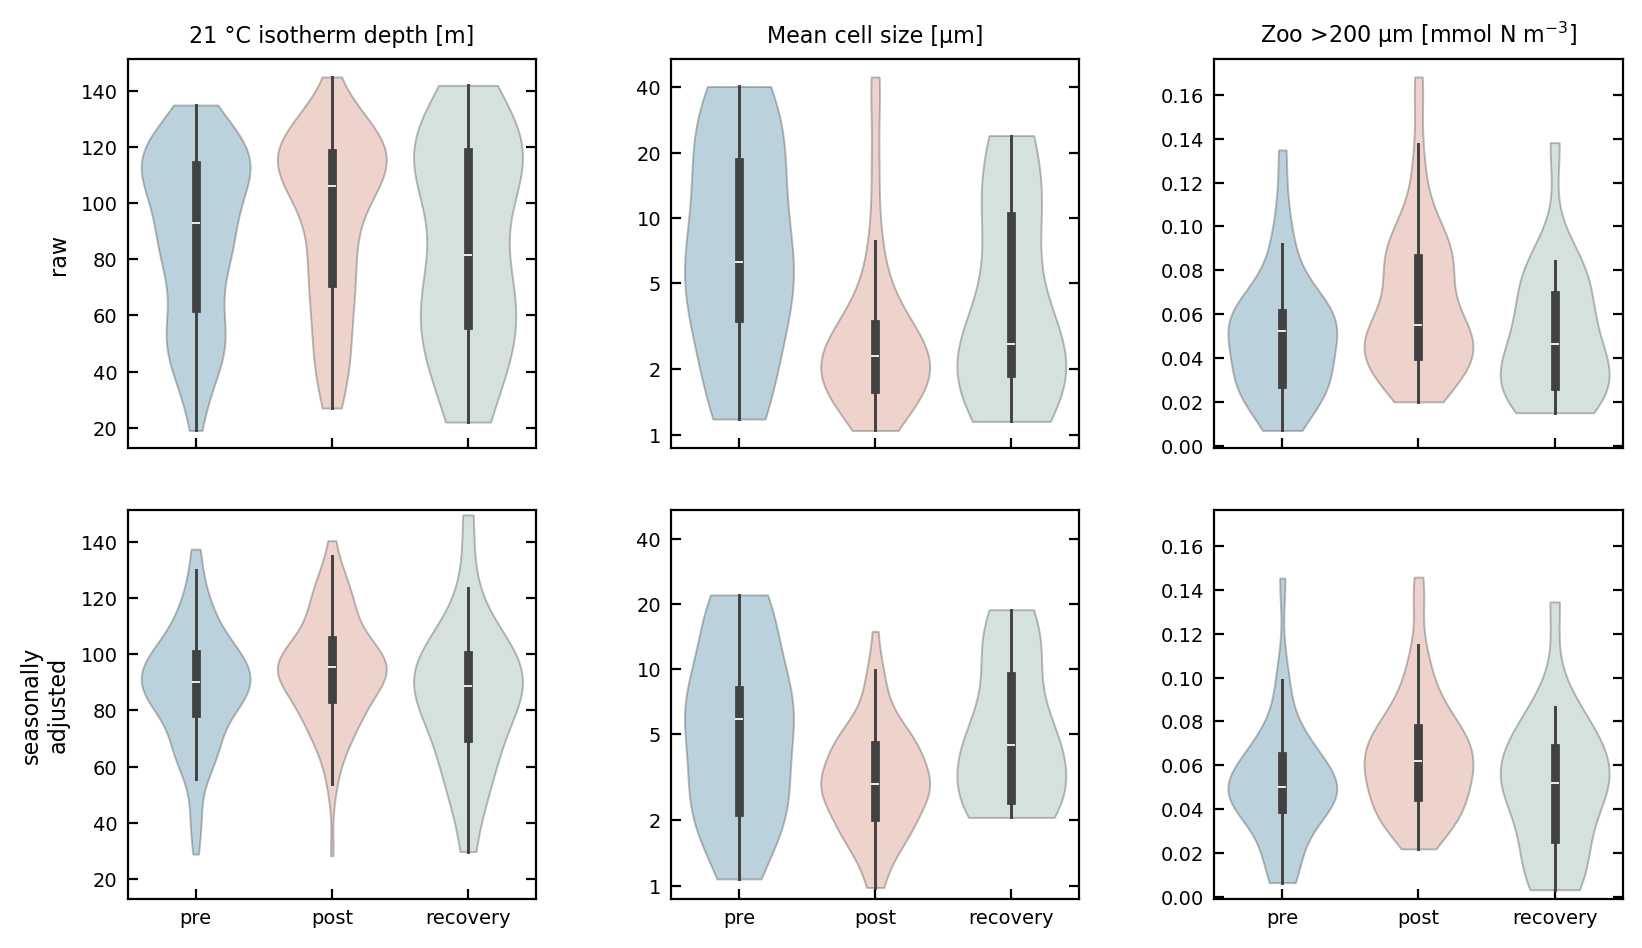

metric           era         SD raw   SD adj  var kept  skew raw  skew adj
Isotherm_21      pre         30.088   20.709       47%     -0.47     -0.30
Isotherm_21      post        30.345   19.253       40%     -0.66     -0.27
Isotherm_21      recovery    36.427   25.909       51%     -0.18      0.16
size_centroid    pre          0.480    0.392       67%     -0.04      0.03
size_centroid    post         0.363    0.241       44%      1.83      0.34
size_centroid    recovery     0.452    0.327       53%      0.54      0.50
zoo_gt200_mmolN  pre          0.028    0.027       93%      0.93      1.13
zoo_gt200_mmolN  post         0.033    0.027       66%      1.06      0.92
zoo_gt200_mmolN  recovery     0.030    0.031      109%      1.12      0.53


In [27]:
%config InlineBackend.figure_format='retina'
# Diagnostic — how seasonal adjustment reshapes the distribution (raw vs seasonally adjusted), by era.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from cariaco_obs import DEFAULT_CSV_PATH

ERA=['pre','post','recovery']; EC={'pre':'#2E86AB','post':'#E07A5F','recovery':'#81B29A'}
df=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
df['era']=np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery'))
df['mo']=df.date.dt.month
UM=[1,2,5,10,20,40]
METRICS=[('Isotherm_21','21 °C isotherm depth [m]',False),
         ('size_centroid','Mean cell size [µm]',True),
         ('zoo_gt200_mmolN','Zoo >200 µm [mmol N m$^{-3}$]',False)]

fig,axes=plt.subplots(2,3,figsize=(8.4,5.0),sharex='col')
fig.subplots_adjust(left=0.10,right=0.99,top=0.91,bottom=0.07,wspace=0.33,hspace=0.16)
stats={}
for j,(col,lab,umlog) in enumerate(METRICS):
    d=df.dropna(subset=[col]).copy()
    d['raw']=d[col]
    d['adj']=(d[col]-d.groupby('mo')[col].transform('mean'))+d[col].mean()
    lo,hi=d['raw'].min(),d['raw'].max(); pad=0.05*(hi-lo)
    for row,which in enumerate(['raw','adj']):
        ax=axes[row,j]
        sns.violinplot(data=d,x='era',y=which,order=ERA,hue='era',palette=EC,legend=False,
                       inner='box',cut=0,linewidth=0.7,ax=ax)
        for v in ax.collections: v.set_alpha(0.35)
        ax.set_ylim(lo-pad,hi+pad)
        if umlog: ax.set_yticks([np.log10(u) for u in UM]); ax.set_yticklabels(UM)
        ax.set_xlabel(''); ax.tick_params(labelsize=7,direction='in',right=True,top=False)
        ax.set_ylabel(('raw' if row==0 else 'seasonally\nadjusted') if j==0 else '',fontsize=8)
        if row==0: ax.set_title(lab,fontsize=8)
        ax.set_xticklabels(ERA if row==1 else [],fontsize=7)
        for e in ERA:
            v=d[d.era==e][which].dropna(); stats[(col,which,e)]=(v.std(),skew(v))
plt.show()

print(f"{'metric':16s} {'era':9s} {'SD raw':>8s} {'SD adj':>8s} {'var kept':>9s} {'skew raw':>9s} {'skew adj':>9s}")
for col,lab,_ in METRICS:
    for e in ERA:
        sdr,skr=stats[(col,'raw',e)]; sda,ska=stats[(col,'adj',e)]
        print(f"{col:16s} {e:9s} {sdr:>8.3f} {sda:>8.3f} {100*(sda/sdr)**2:>8.0f}% {skr:>9.2f} {ska:>9.2f}")

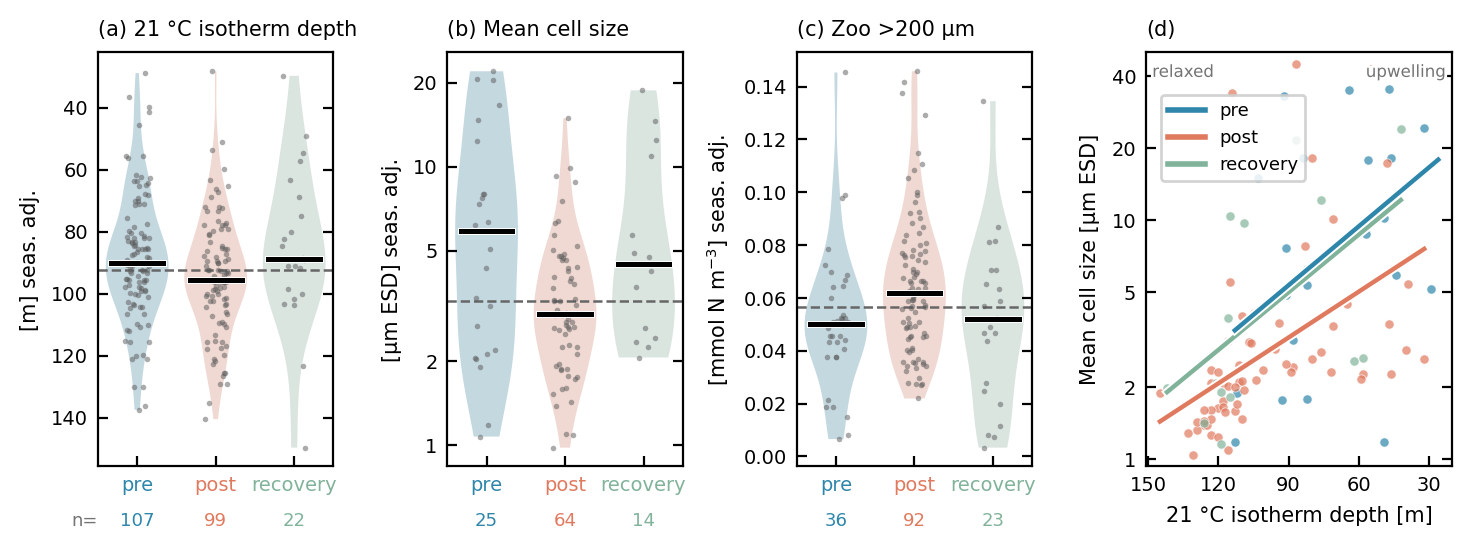

In [31]:
%config InlineBackend.figure_format='retina'
# Figure 3 — (a)(b)(c) seasonally-adjusted era violins | (d) raw MCS vs isotherm scaling.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns, matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from cariaco_obs import DEFAULT_CSV_PATH

ERA=['pre','post','recovery']; EC={'pre':'#2E86AB','post':'#E07A5F','recovery':'#81B29A'}
HALO=[pe.withStroke(linewidth=2.5,foreground='white')]; HALO3=[pe.withStroke(linewidth=3.0,foreground='white')]
LBL=[pe.withStroke(linewidth=2,foreground='white')]; UM_A=[1,2,5,10,20]; UM_D=[1,2,5,10,20,40]

df=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
df['era']=np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery'))
df['mo']=df.date.dt.month

fig=plt.figure(figsize=(7.4,3.0))
gs=GridSpec(1,4,figure=fig,width_ratios=[1,1,1,1.3],left=0.07,right=0.985,top=0.86,bottom=0.17,wspace=0.45)
axA,axB,axC,axD=[fig.add_subplot(gs[0,i]) for i in range(4)]

def era_axis(ax,counts,first=False):
    ax.set_xticks(range(3)); ax.set_xticklabels(ERA,fontsize=7)
    for t,e in zip(ax.get_xticklabels(),ERA): t.set_color(EC[e])
    for i,e in enumerate(ERA):
        ax.text(i,-0.11,str(counts[i]),transform=ax.get_xaxis_transform(),ha='center',va='top',fontsize=6.5,color=EC[e],clip_on=False)
    if first:
        ax.text(-0.5,-0.11,'n=',transform=ax.get_xaxis_transform(),ha='right',va='top',fontsize=6.5,color='0.45',clip_on=False)

def violin(ax,col,ylabel,title,first=False,umlog=False,invert=False):
    d=df.dropna(subset=[col]).copy()
    d['adj']=(d[col]-d.groupby('mo')[col].transform('mean'))+d[col].mean()
    sns.violinplot(data=d,x='era',y='adj',order=ERA,hue='era',palette=EC,legend=False,
                   inner=None,cut=0,linewidth=0.7,ax=ax)
    for v in ax.collections: v.set_alpha(0.30); v.set_edgecolor('none')
    sns.stripplot(data=d,x='era',y='adj',order=ERA,color='0.35',size=2.0,alpha=0.5,jitter=0.16,ax=ax)
    for i,e in enumerate(ERA):
        m=d[d.era==e]['adj'].median(); ax.plot([i-0.33,i+0.33],[m,m],color='k',lw=1.8,zorder=6,path_effects=HALO)
    ax.axhline(d['adj'].median(),color='0.4',ls='--',lw=0.9,zorder=1); ax.set_xlim(-0.5,2.5)
    if umlog: ax.set_yticks([np.log10(u) for u in UM_A]); ax.set_yticklabels(UM_A)
    if invert: ax.invert_yaxis()
    ax.set_ylabel(ylabel,fontsize=7.5); ax.set_xlabel(''); ax.set_title(title,loc='left',fontsize=7.5)
    ax.tick_params(top=False,right=True,direction='in',labelsize=7)
    era_axis(ax,[len(d[d.era==e]) for e in ERA],first=first)

violin(axA,'Isotherm_21','[m] seas. adj.','(a) 21 °C isotherm depth',first=True,invert=True)
violin(axB,'size_centroid','[µm ESD] seas. adj.','(b) Mean cell size',umlog=True)
violin(axC,'zoo_gt200_mmolN','[mmol N m$^{-3}$] seas. adj.','(c) Zoo >200 µm')

# (d) raw MCS vs Isotherm scaling
df['mcs_log']=df['size_centroid']
d=df.dropna(subset=['mcs_log','Isotherm_21']).copy()
for e in ERA:
    s=d[d.era==e]
    axD.scatter(s['Isotherm_21'],s['mcs_log'],s=11,color=EC[e],alpha=0.7,edgecolor='white',linewidth=0.3,zorder=3)
    if len(s)>=8:
        b=np.polyfit(s['Isotherm_21'],s['mcs_log'],1); xx=np.linspace(s['Isotherm_21'].min(),s['Isotherm_21'].max(),50)
        axD.plot(xx,np.polyval(b,xx),color=EC[e],lw=1.6,zorder={'pre':7,'post':6,'recovery':5}[e],path_effects=HALO3)
axD.invert_xaxis(); axD.set_ylim(d['mcs_log'].min()-0.05,d['mcs_log'].max()+0.05)
axD.set_yticks([np.log10(u) for u in UM_D]); axD.set_yticklabels(UM_D)
axD.xaxis.set_major_locator(MaxNLocator(nbins=5))
axD.set_ylabel('Mean cell size [µm ESD]',fontsize=7.5); axD.set_xlabel('21 °C isotherm depth [m]',fontsize=7.5)
axD.set_title('(d)',loc='left',fontsize=7.5); axD.tick_params(top=False,right=True,direction='in',labelsize=7)
axD.text(0.02,0.97,'relaxed',transform=axD.transAxes,ha='left',va='top',fontsize=6,color='0.45',path_effects=LBL)
axD.text(0.98,0.97,'upwelling',transform=axD.transAxes,ha='right',va='top',fontsize=6,color='0.45',path_effects=LBL)
axD.legend(handles=[Line2D([0],[0],color=EC[e],lw=2,label=e) for e in ERA],loc='upper left',
           bbox_to_anchor=(0.02,0.92),frameon=True,framealpha=0.85,edgecolor='0.8',fontsize=6.5)
plt.show()

In [29]:
# Fig 3 stats on the figure's variables — Cliff δ + KS, deseasonalised.
# Table 1 pooled (main) | Table 2 regime split (supplementary).
import numpy as np, pandas as pd
from scipy.stats import ks_2samp, mannwhitneyu
from cariaco_obs import DEFAULT_CSV_PATH

df=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
df['era']=np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery'))
df['mo']=df.date.dt.month
reg='regime_adjusted' if 'regime_adjusted' in df.columns else 'upwelling'
VARS=[('N (isotherm)','Isotherm_21'),('P (MCS)','size_centroid'),('Z (zoo>200)','zoo_gt200_mmolN')]
PAIRS=[('pre','post'),('recovery','post'),('pre','recovery')]

def cliff(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float); a=a[~np.isnan(a)]; b=b[~np.isnan(b)]
    return np.nan if(len(a)<2 or len(b)<2) else np.sign(a[:,None]-b[None,:]).mean()
def ks(a,b):
    a=pd.Series(a).dropna(); b=pd.Series(b).dropna()
    return np.nan if(len(a)<3 or len(b)<3) else ks_2samp(a,b).statistic
def mw(a,b):
    a=pd.Series(a).dropna(); b=pd.Series(b).dropna()
    return np.nan if(len(a)<3 or len(b)<3) else mannwhitneyu(a,b,alternative='two-sided')[1]

A={}
for vlab,col in VARS:
    s=df.dropna(subset=[col]).copy(); s['anom']=s[col]-s.groupby('mo')[col].transform('mean'); A[vlab]=s
def row(vlab,sub,a,b):
    x=sub[sub.era==a]['anom']; y=sub[sub.era==b]['anom']
    return (f"{vlab:13s} {a+'-'+b:16s} {f'{x.notna().sum()},{y.notna().sum()}':>8s} "
            f"{x.median():>7.3f} {y.median():>7.3f} {cliff(x,y):>+6.2f} {ks(x,y):>5.2f} {mw(x,y):>7.2g}")
hdr=f"{'var':13s} {'pair':16s} {'n1,n2':>8s} {'med1':>7s} {'med2':>7s} {'δ':>6s} {'KS':>5s} {'p':>7s}"

print("TABLE 1 — POOLED (deseasonalised).  δ=Cliff location | KS=distribution | p=MW (optimistic; lean on δ/KS + figure)")
print(hdr)
for vlab,_ in VARS:
    for a,b in PAIRS: print(row(vlab,A[vlab],a,b))
    print()
print("\nTABLE 2 — REGIME SPLIT (deseasonalised; supplementary; small n).")
print(f"{'regime':10s} "+hdr)
for regime in ['upwelling','relaxed']:
    for vlab,_ in VARS:
        sub=A[vlab][A[vlab][reg]==regime]
        for a,b in PAIRS: print(f"{regime:10s} "+row(vlab,sub,a,b))
        print()

TABLE 1 — POOLED (deseasonalised).  δ=Cliff location | KS=distribution | p=MW (optimistic; lean on δ/KS + figure)
var           pair                n1,n2    med1    med2      δ    KS       p
N (isotherm)  pre-post           107,99  -0.632   4.632  -0.17  0.15   0.037
N (isotherm)  recovery-post       22,99  -2.018   4.632  -0.25  0.28   0.073
N (isotherm)  pre-recovery       107,22  -0.632  -2.018  +0.09  0.14    0.49

P (MCS)       pre-post            25,64   0.196  -0.101  +0.35  0.42   0.011
P (MCS)       recovery-post       14,64   0.079  -0.101  +0.33  0.30   0.052
P (MCS)       pre-recovery        25,14   0.196   0.079  +0.04  0.23    0.85

Z (zoo>200)   pre-post            36,92  -0.009   0.002  -0.28  0.32   0.014
Z (zoo>200)   recovery-post       23,92  -0.007   0.002  -0.26  0.25   0.054
Z (zoo>200)   pre-recovery        36,23  -0.009  -0.007  -0.03  0.14    0.86


TABLE 2 — REGIME SPLIT (deseasonalised; supplementary; small n).
regime     var           pair                n1

In [30]:
# Panel (d) fits + ANCOVA on Isotherm_21 (supplementary to the figure). MCS in log10 µm.
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

df=pd.read_csv(DEFAULT_CSV_PATH,parse_dates=['date'])
df['era']=np.where(df.date.dt.year<2005,'pre',np.where(df.date.dt.year<2014,'post','recovery'))
df['mcs_log']=df['size_centroid']
X='Isotherm_21'
d=df.dropna(subset=['mcs_log',X]).copy()

print("Per-era fits  (MCS = 10^(a + b·isotherm); b in log10 µm per m):")
print(f"{'era':9s} {'n':>4s} {'slope_b':>10s} {'intcpt_a':>9s} {'R2':>6s} {'rho':>7s} {'p':>9s}")
for e in ['all','pre','post','recovery']:
    s=d if e=='all' else d[d.era==e]
    b,a=np.polyfit(s[X],s['mcs_log'],1)
    yhat=a+b*s[X]; r2=1-((s['mcs_log']-yhat)**2).sum()/((s['mcs_log']-s['mcs_log'].mean())**2).sum()
    rho,p=spearmanr(s[X],s['mcs_log'])
    print(f"{e:9s} {len(s):>4d} {b:>10.5f} {a:>9.3f} {r2:>6.2f} {rho:>7.3f} {p:>9.2g}")

print("\nANCOVA (reference = post):")
add=smf.ols('mcs_log ~ Isotherm_21 + C(era, Treatment(reference="post"))',data=d).fit()
aov=sm.stats.anova_lm(add,typ=2); er=[r for r in aov.index if 'era' in r][0]
print(f"  additive  MCS ~ isotherm + era :  era level-shift F={aov.loc[er,'F']:.2f}  p={aov.loc[er,'PR(>F)']:.3g}")
print("  era offsets vs post at matched isotherm:")
for name,coef in add.params.items():
    if 'C(era' in name:
        who=name.split('[T.')[1].rstrip(']')
        print(f"    {who:9s} {coef:+.3f} log10 µm = {10**coef:.2f}×   (p={add.pvalues[name]:.3g})")
inter=smf.ols('mcs_log ~ Isotherm_21 * C(era, Treatment(reference="post"))',data=d).fit()
aovi=sm.stats.anova_lm(inter,typ=2); ix=[r for r in aovi.index if ':' in r][0]
print(f"  interaction (slope difference): F={aovi.loc[ix,'F']:.2f}  p={aovi.loc[ix,'PR(>F)']:.3g}  (n.s. => parallel slopes)")

ann=d.assign(yr=d.date.dt.year).groupby('yr').agg(mcs_log=('mcs_log','mean'),x=(X,'mean')).reset_index()
ann['era']=np.where(ann.yr<2005,'pre',np.where(ann.yr<2014,'post','recovery'))
add_a=smf.ols('mcs_log ~ x + C(era, Treatment(reference="post"))',data=ann).fit()
aov_a=sm.stats.anova_lm(add_a,typ=2); er_a=[r for r in aov_a.index if 'era' in r][0]
print(f"  annual-mean cross-check (n_years={len(ann)}): era F={aov_a.loc[er_a,'F']:.2f}  p={aov_a.loc[er_a,'PR(>F)']:.3g}")
print("\nCaveat: months autocorrelated -> per-month p's optimistic; the offsets (×fold) carry the weight, annual check is the conservative read.")

Per-era fits  (MCS = 10^(a + b·isotherm); b in log10 µm per m):
era          n    slope_b  intcpt_a     R2     rho         p
all        103   -0.00812     1.329   0.31  -0.674     6e-15
pre         25   -0.00821     1.466   0.23  -0.487     0.014
post        64   -0.00639     1.083   0.24  -0.729   8.2e-12
recovery    14   -0.00803     1.421   0.28  -0.692    0.0061

ANCOVA (reference = post):
  additive  MCS ~ isotherm + era :  era level-shift F=3.94  p=0.0225
  era offsets vs post at matched isotherm:
    pre       +0.231 log10 µm = 1.70×   (p=0.0119)
    recovery  +0.173 log10 µm = 1.49×   (p=0.103)
  interaction (slope difference): F=0.22  p=0.8  (n.s. => parallel slopes)
  annual-mean cross-check (n_years=15): era F=5.19  p=0.0259

Caveat: months autocorrelated -> per-month p's optimistic; the offsets (×fold) carry the weight, annual check is the conservative read.
